# H-CAST Output Analysis

This notebook analyzes seeded training/test artifacts in `/scratch/g.saggini1/outputs/`. Each experiment is a parent directory containing `seed_<seed>` runs; curves and final metrics report the mean and sample standard deviation across those seeds.

It compares:

- H-CAST global-KL and no-KL baselines: `hcast_<dataset>` and `hcast_<dataset>_nokl`
- HCC variants: `hcast_hcc_<dataset>_step_<epoch>epoch[_nokl]`
- lexicographic variants: `hcast_lex_<dataset>[_step_80epoch]`
- orthonormal plugin variants: `hcast_<dataset>_orthonormal_plugin_*`

It includes:
- validation curves for `fpa_topdown` and `weighted_ap_topdown`,
- per-level validation top-down accuracy curves,
- a final test comparison table with deltas,
- projection diagnostics (`proj_constraint_alpha`, `proj_constraint_strength`, `proj_temperature`, etc.),
- short interpretation snippets after each analysis block.


In [11]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'configs').exists() else cwd.parent
notebook_utils_dir = repo_root / 'notebooks'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from hcast_analysis_utils import HCastAnalysis, HCastAnalysisConfig, resolve_project_root

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [12]:
INCLUDE_BASELINES = True
INCLUDE_TOPDOWN_METRICS = True
BASELINE_COLOR = '#243ab4'

DATASET_SLUGS = {
    'cifar-100': 'cifar100',
    'cub-200-2011': 'cub200',
    'fgvc-aircraft': 'aircraft',
}
HCAST_DATASETS = tuple(DATASET_SLUGS.values())

BASELINE_BY_DATASET = {
    dataset_key: {'run_dir': f'hcast_{dataset}', 'label': 'H-CAST global KL'}
    for dataset_key, dataset in DATASET_SLUGS.items()
}

PLUGIN_LOSS_MODE = 'level_softmax_ce_reg'
PLUGIN_LOSS_LABEL = 'level softmax CE+reg'

MANUAL_RUNS = [
    # # No-KL H-CAST baselines
    # *[
    #     {'run_dir': f'hcast_{dataset}_nokl', 'label': 'H-CAST no global KL'}
    #     for dataset in HCAST_DATASETS
    # ],

    # # HCC variants
    # *[
    #     {'run_dir': f'hcast_hcc_{dataset}_step_{epoch}epoch{suffix}',
    #      'label': f'H-CAST HCC step@{epoch} {kl_label}'}
    #     for dataset in HCAST_DATASETS
    #     for epoch in (0, 80)
    #     for suffix, kl_label in (('', 'global KL'), ('_nokl', 'no global KL'))
    # ],

    # Gradient-space lexicographic H-CAST variants
    *[
        {'run_dir': f'hcast_{dataset}_lex',
         'label': f'H-CAST lex'}
        for dataset in HCAST_DATASETS
    ],

    # H-CAST with the shared orthonormal plugin
    *[
        {'run_dir': f'hcast_{dataset}_orthonormal_plugin_{PLUGIN_LOSS_MODE}_{transform_mode}{frame_mode}',
         'label': f'H-CAST plugin {PLUGIN_LOSS_LABEL} {transform_mode} {frame_mode}'}
        for dataset in HCAST_DATASETS
        for transform_mode in ('final_only', 'bn_linear')
        for frame_mode in ('', '_orthonormal_block_random', '_identity')
    ],

    # H-CAST with the shared orthonormal plugin lex mode
    *[
        {'run_dir': f'hcast_{dataset}_orthonormal_plugin_{PLUGIN_LOSS_MODE}_lex_{mode}_final_only',
         'label': f'H-CAST plugin {PLUGIN_LOSS_LABEL} lex {mode} final_only identity'}
        for dataset in HCAST_DATASETS
        for mode in ('coarse_first', 'fine_first')
    ],
]

TEMPERATURE_COLOR_PALETTE = [
    '#d62728',
    '#2ca02c',
    '#ff7f0e',
    '#9467bd',
    '#8c564b',
    '#17becf',
    '#e377c2',
    '#bcbd22',
]


In [13]:
config = HCastAnalysisConfig(
    outputs_root=OUTPUTS_ROOT,
    include_baselines=INCLUDE_BASELINES,
    include_topdown_metrics=INCLUDE_TOPDOWN_METRICS,
    baseline_color=BASELINE_COLOR,
    baseline_by_dataset=BASELINE_BY_DATASET,
    manual_runs=MANUAL_RUNS,
    temperature_color_palette=TEMPERATURE_COLOR_PALETTE,
)

analysis = HCastAnalysis.from_config(config)
analysis.print_run_summary()


Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hcast_cifar100_orthonormal_plugin_level_softmax_ce_reg_final_only
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hcast_cifar100_orthonormal_plugin_level_softmax_ce_reg_final_only_orthonormal_block_random
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hcast_cifar100_orthonormal_plugin_level_softmax_ce_reg_final_only_identity
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hcast_cifar100_orthonormal_plugin_level_softmax_ce_reg_bn_linear
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hcast_cifar100_orthonormal_plugin_level_softmax_ce_reg_bn_linear_orthonormal_block_random
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hcast_cifar100_orthonormal_plugin_level_softmax_ce_reg_bn_linear_identity
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hcast_cub200_orthonormal_plugin_level_softmax_ce_reg_final_only
Skipping missing/man

## H-CAST Variants: Validation Curves (Per Dataset)

Each panel overlays both decoding modes on the **same axes**:

- color = run
- line style = mode (`topdown` solid, `independent` dashed)

Metrics shown: `FPA`, `wAP`, `TICE`, and `AHD`.


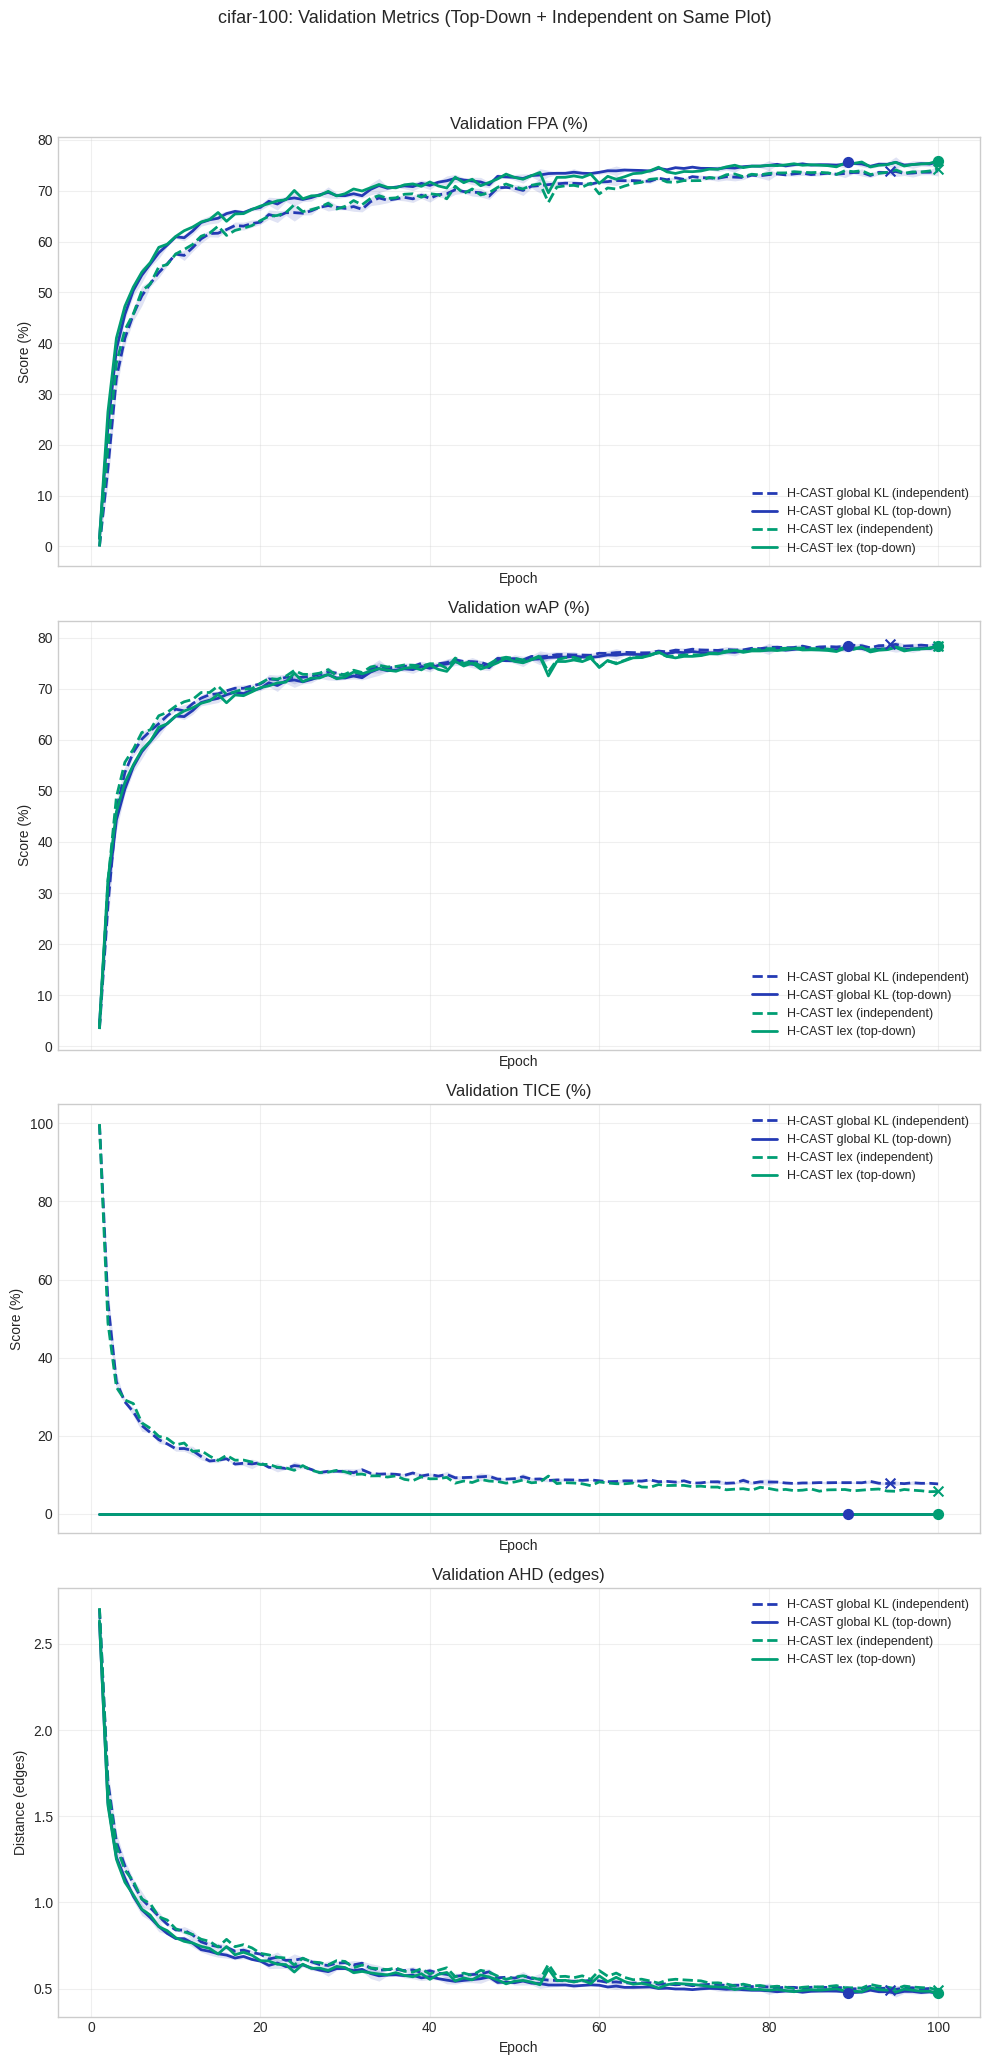

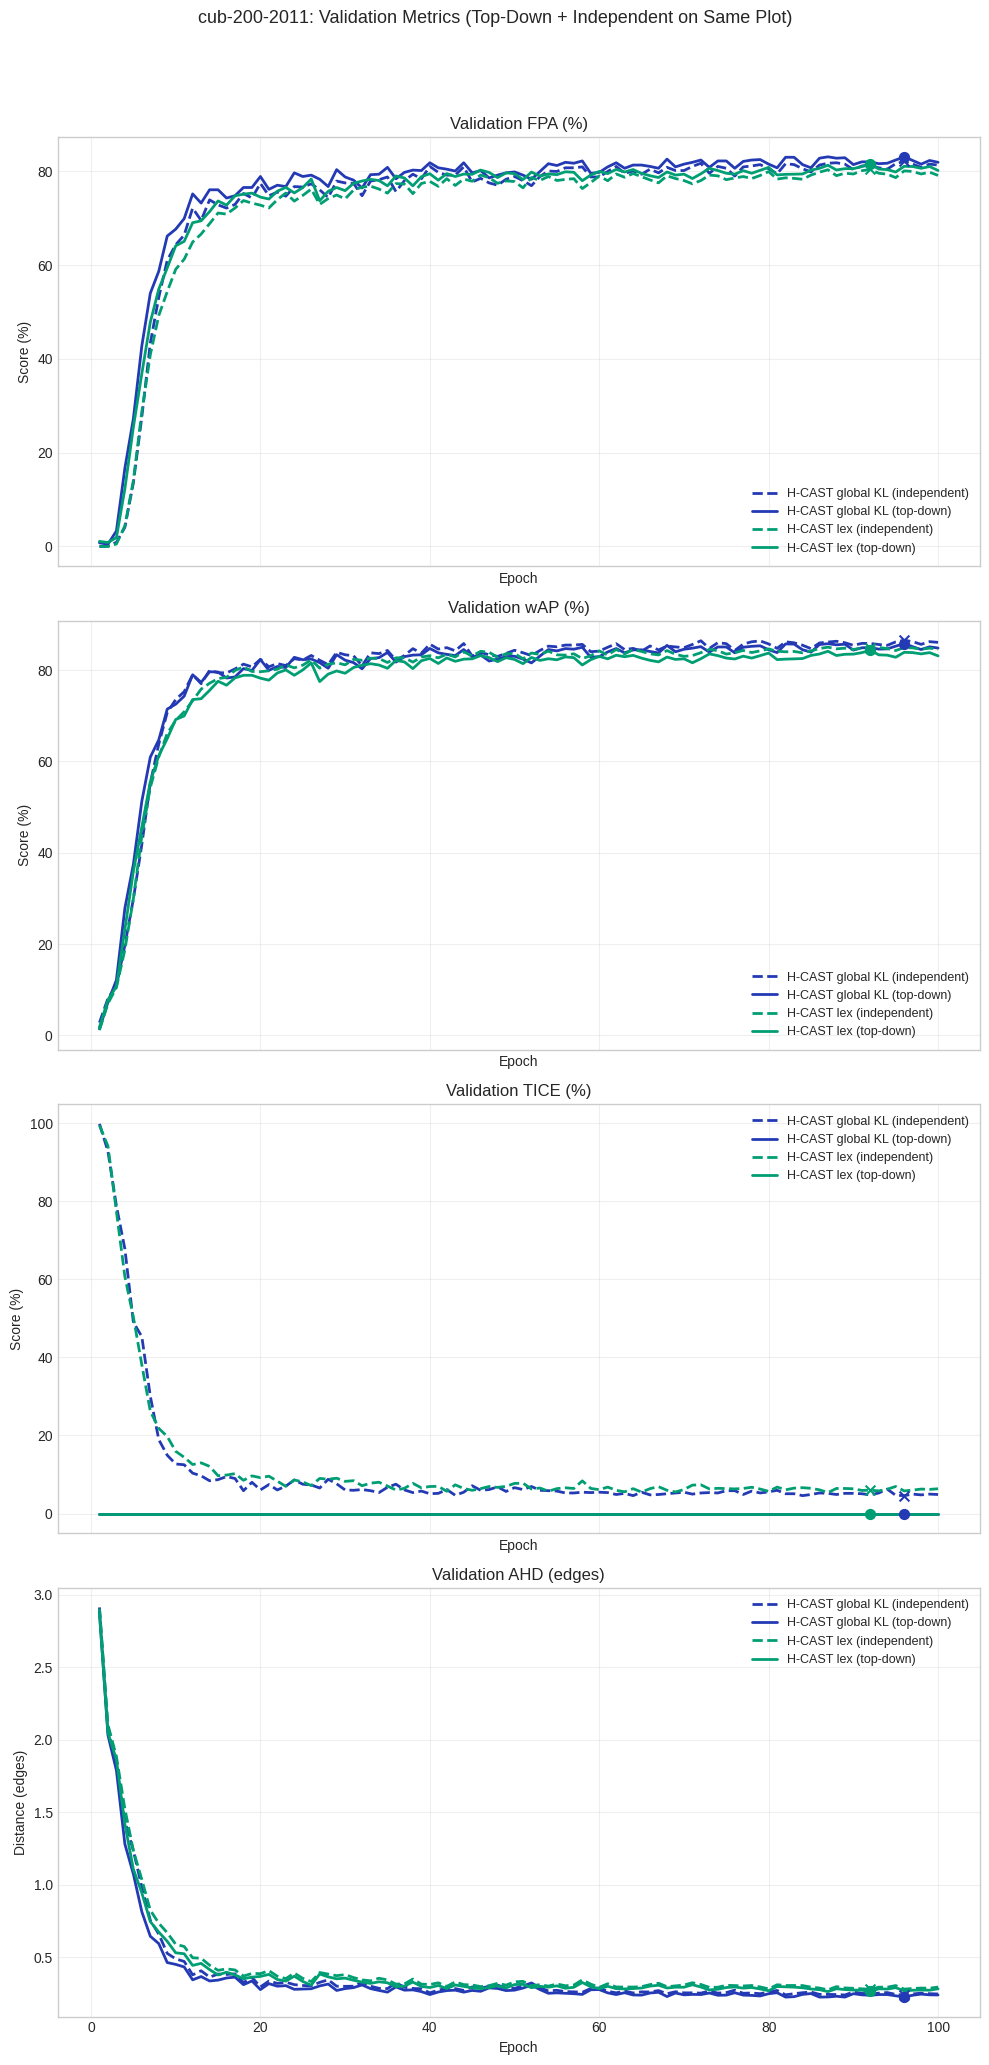

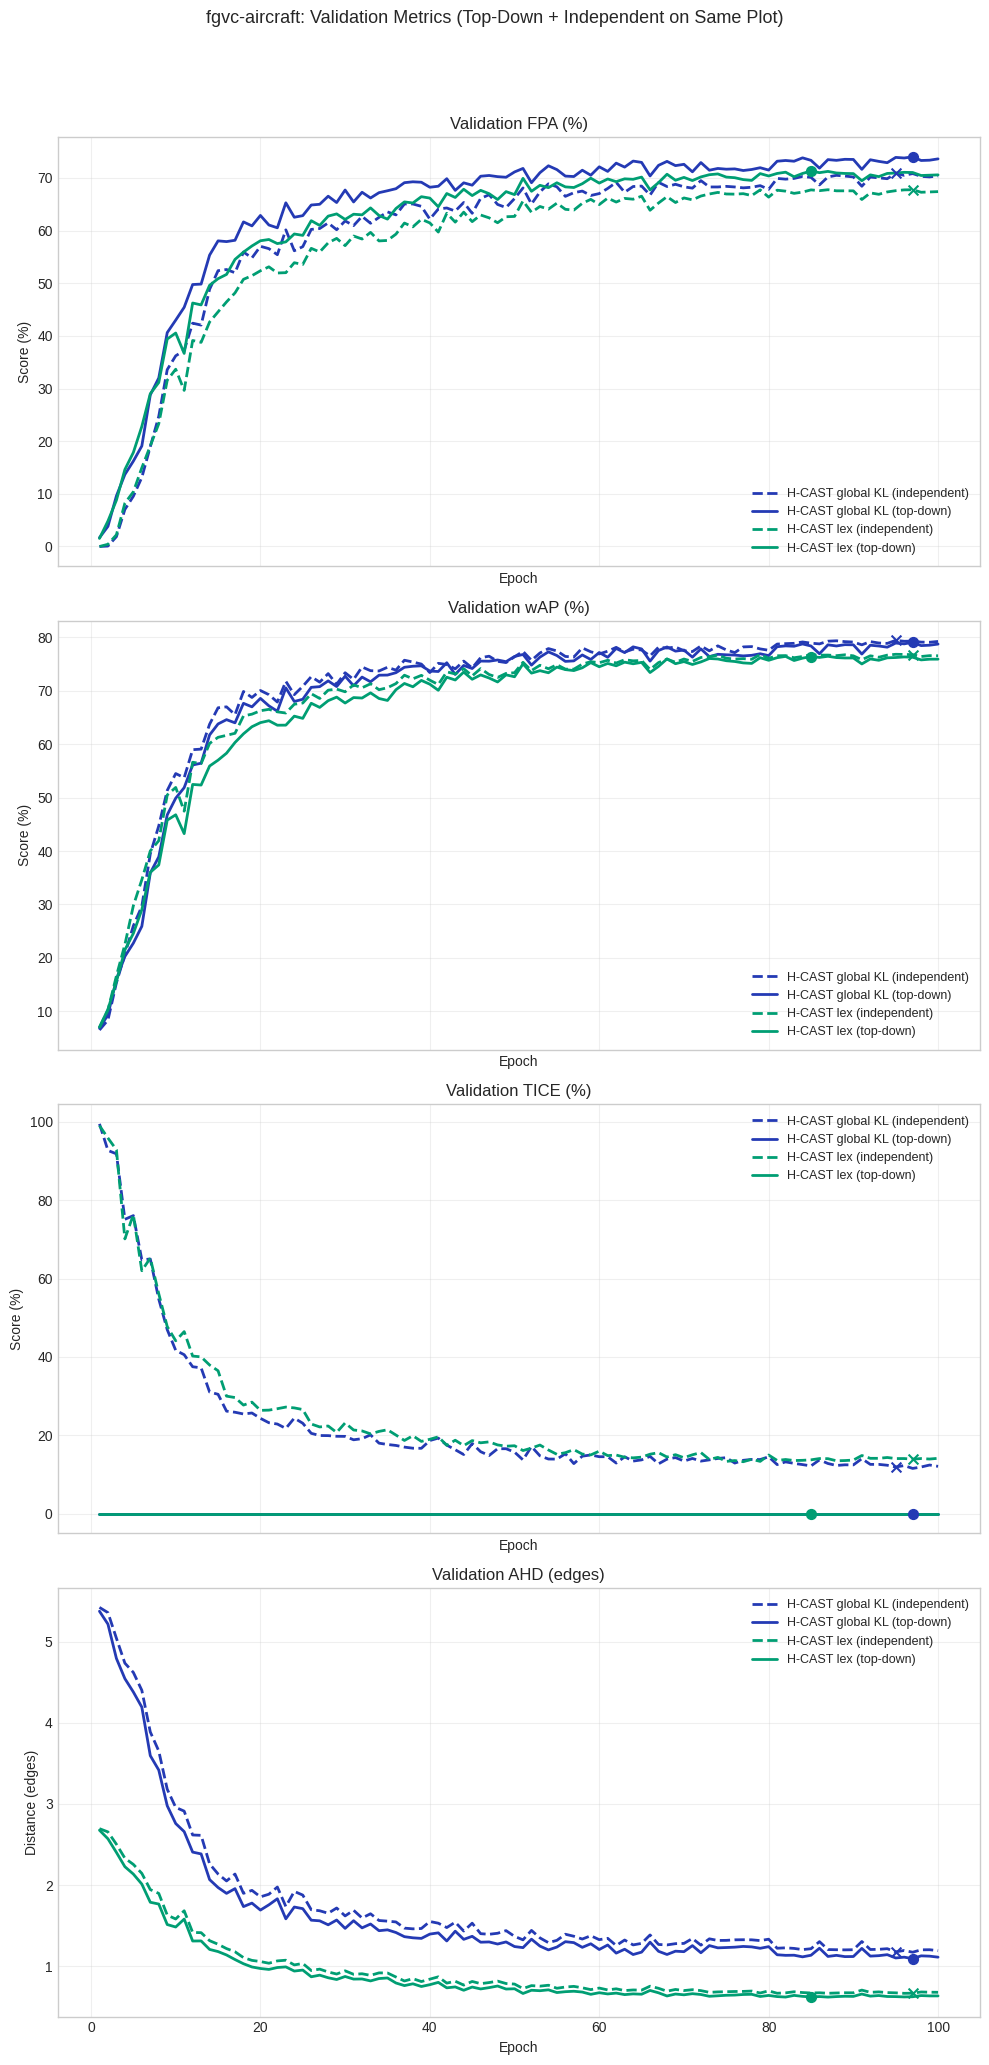

In [14]:
analysis.plot_validation_curves()


Interpretation note:
- For `FPA` and `wAP`, higher is better; for `TICE`, lower is better.
- Compare solid vs dashed lines of the same color to isolate hierarchy-enforcement effects for one run.
- Compare colors at the same line style to compare runs under the same decoding mode.

## Projection Diagnostics (HCC)

This section visualizes projection diagnostics logged in `val_metrics` (when available):
- `proj_constraint_alpha` (annealing blend/schedule value),
- `proj_constraint_strength` (intrinsic projection strength),
- `proj_temperature`,
- `proj_mode_intrinsic_soft`.


In [15]:
analysis.plot_projection_diagnostics()


[cifar-100] No projection diagnostics found in selected runs.
[cub-200-2011] No projection diagnostics found in selected runs.
[fgvc-aircraft] No projection diagnostics found in selected runs.


## Training Loss Comparison

This section compares training losses between runs for both aggregate losses (`total`, `level_ce`, `gk_loss`) and per-level losses (`loss_level_*`).

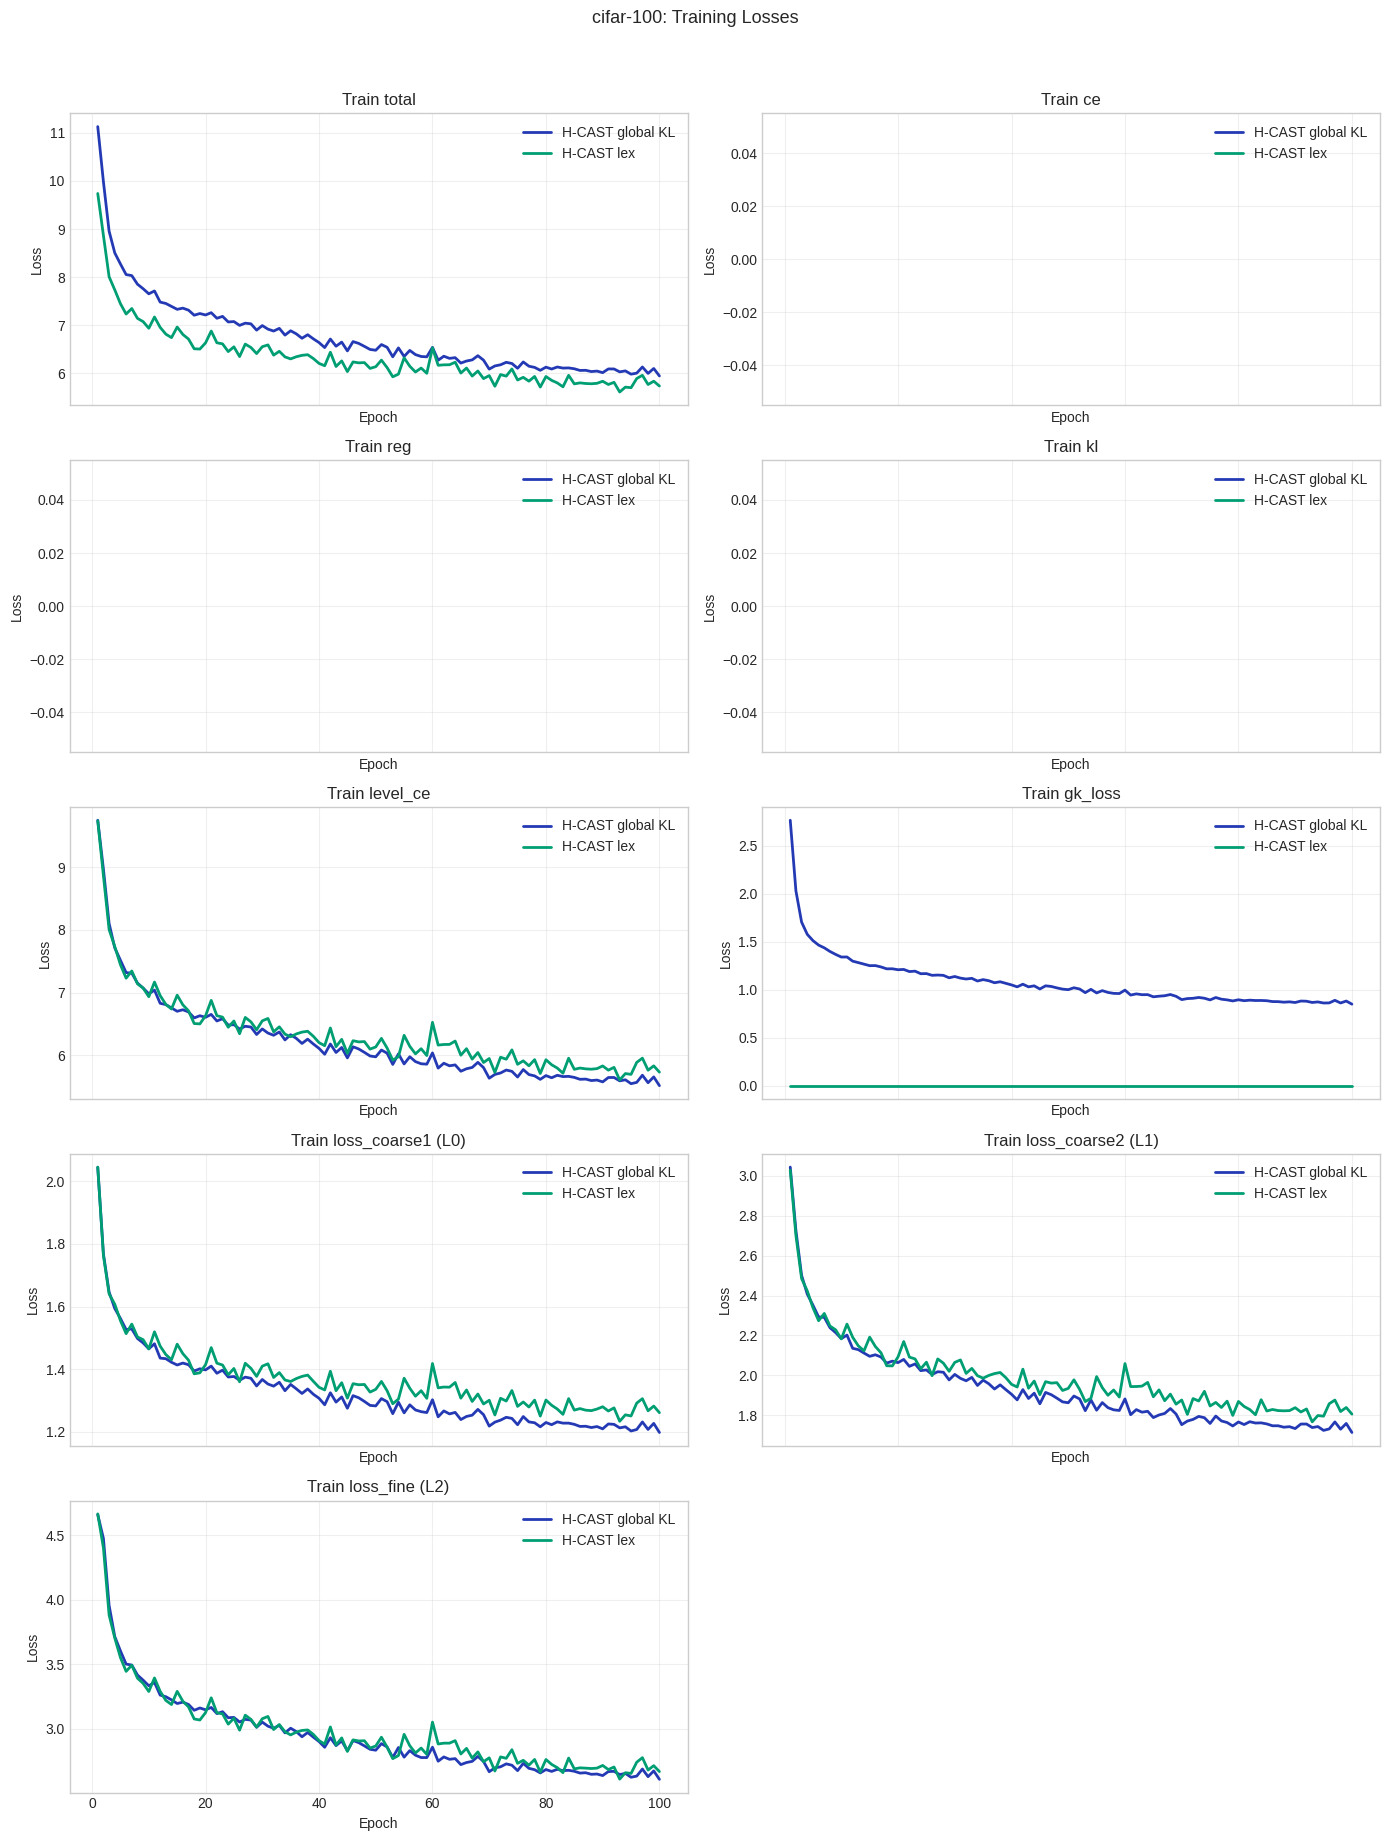

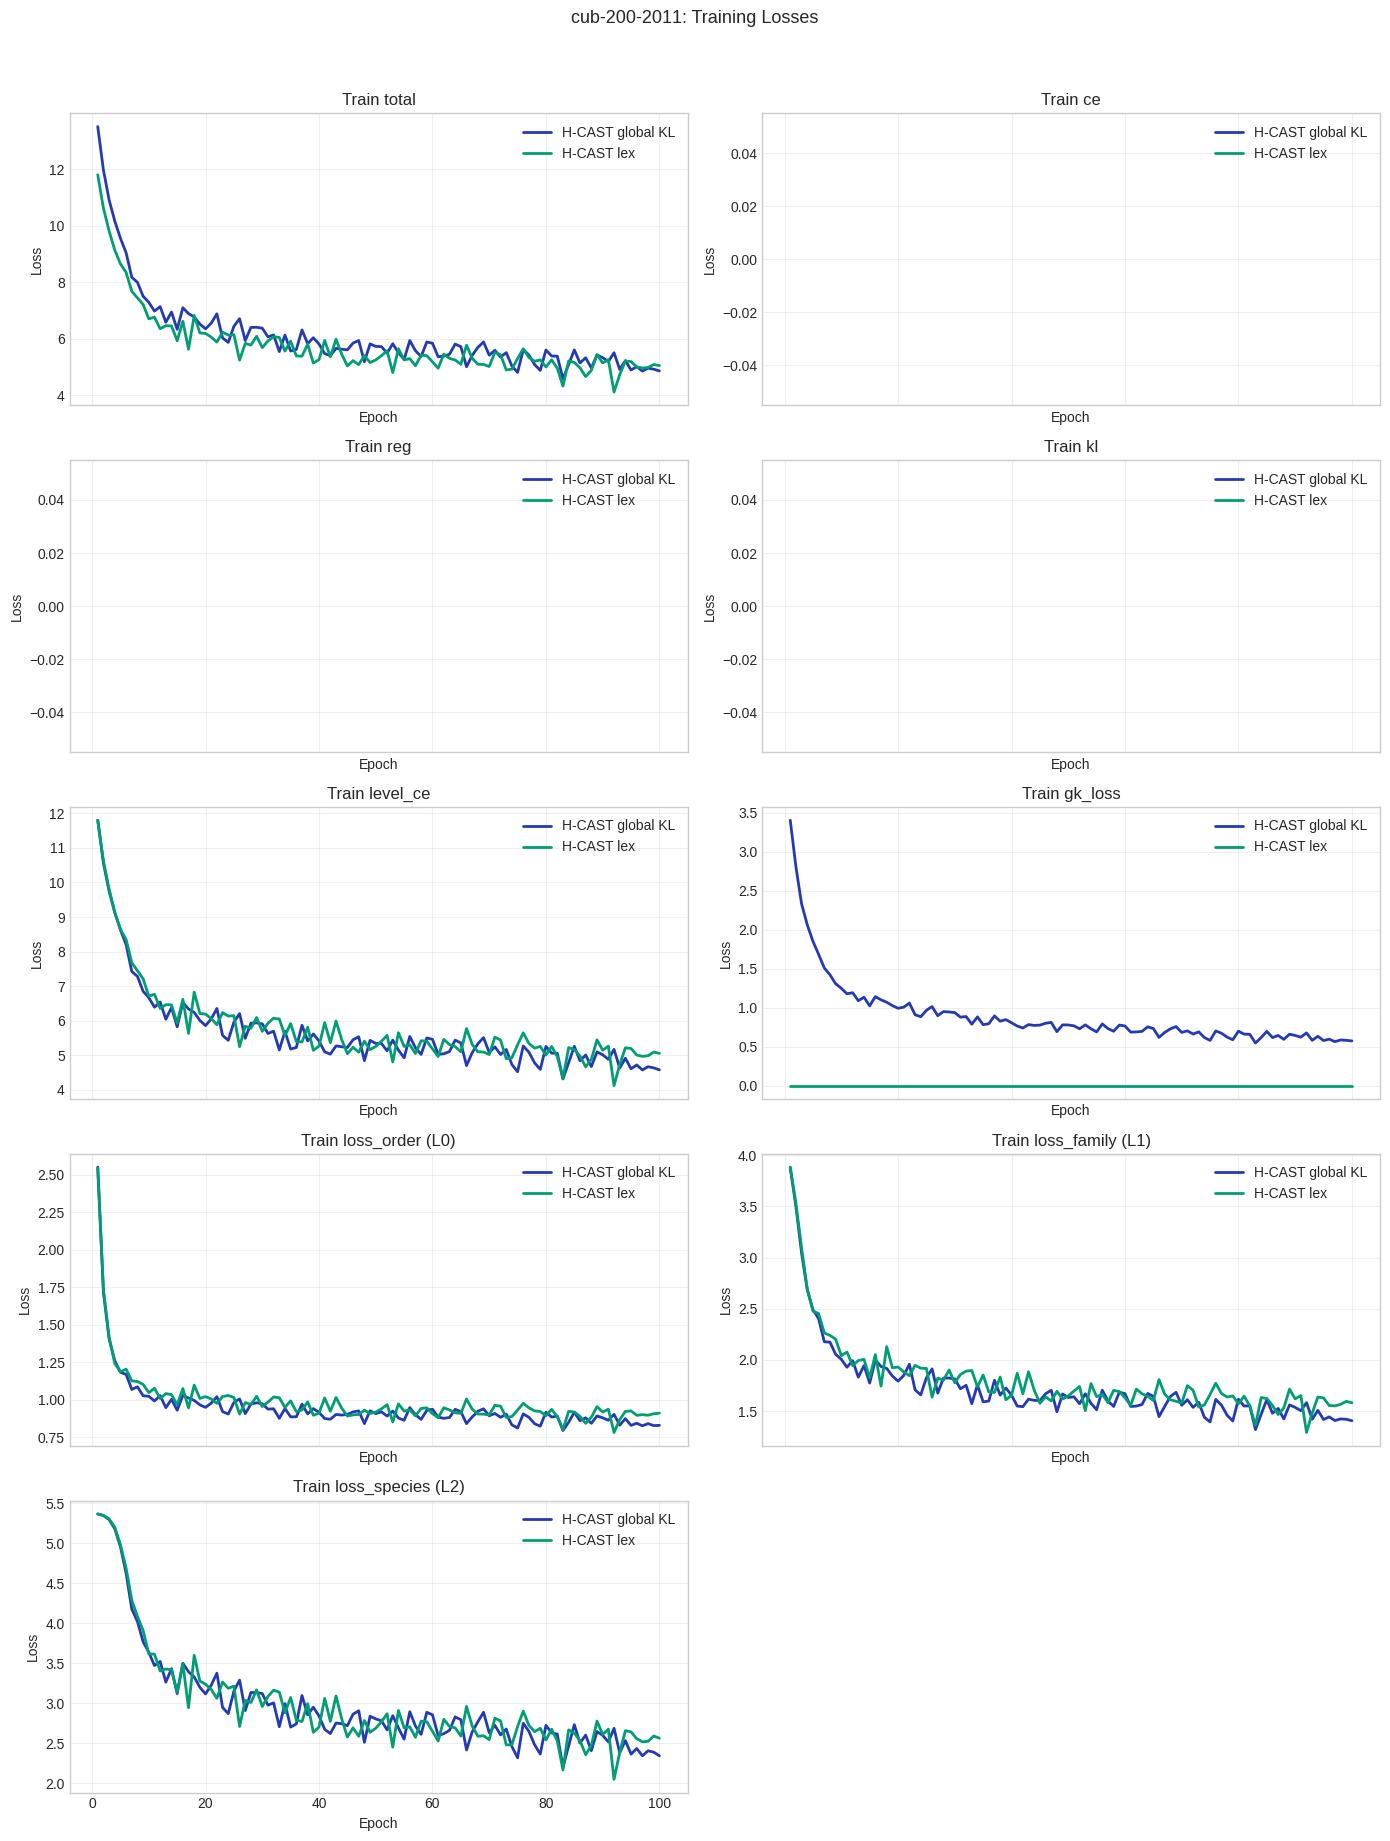

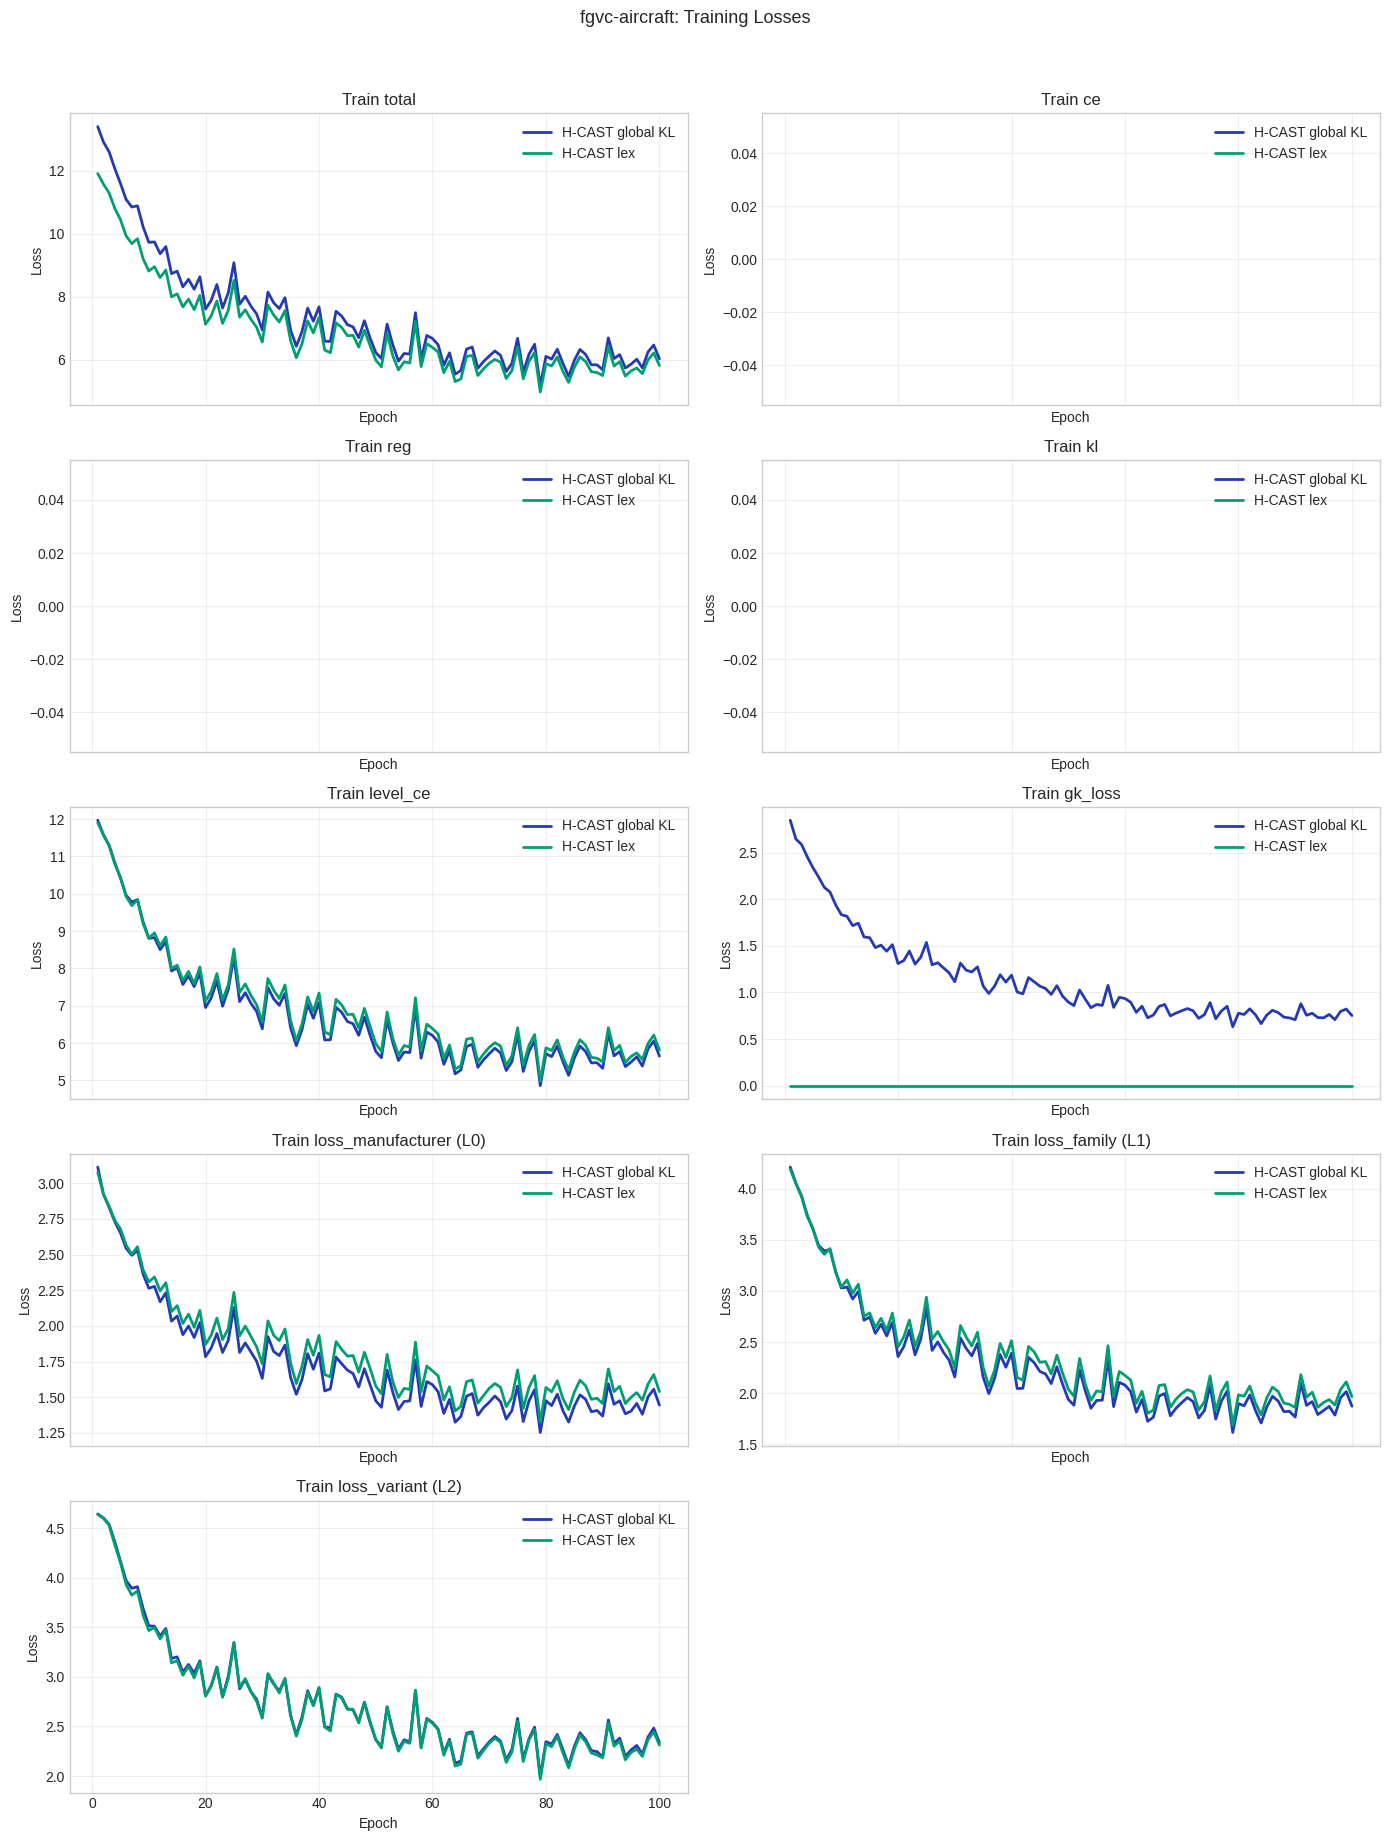

In [16]:
analysis.plot_training_losses()


Interpretation note:
- Lower is better for all loss curves.
- Compare `total` first for optimization behavior, then `loss_level_*` to see where depth-specific training differs.
- If one run has consistently lower shallow-level loss but much higher deep-level loss, expect weaker fine-grained accuracy and path metrics.

## Per-Run Per-Level Training Losses (Per Dataset)

Interpretation note:
- Each chart corresponds to one selected run in its dataset section.
- Lines in the same chart are all available `loss_level_*` training losses (lower is better).



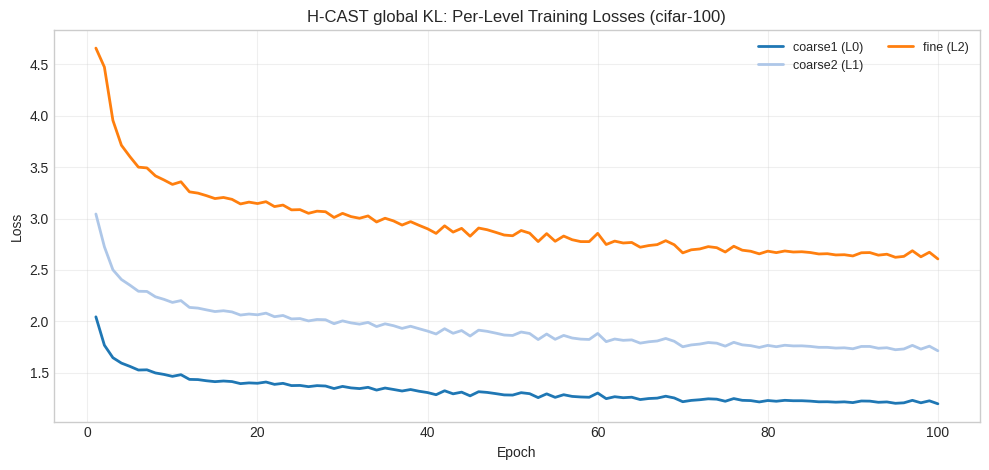

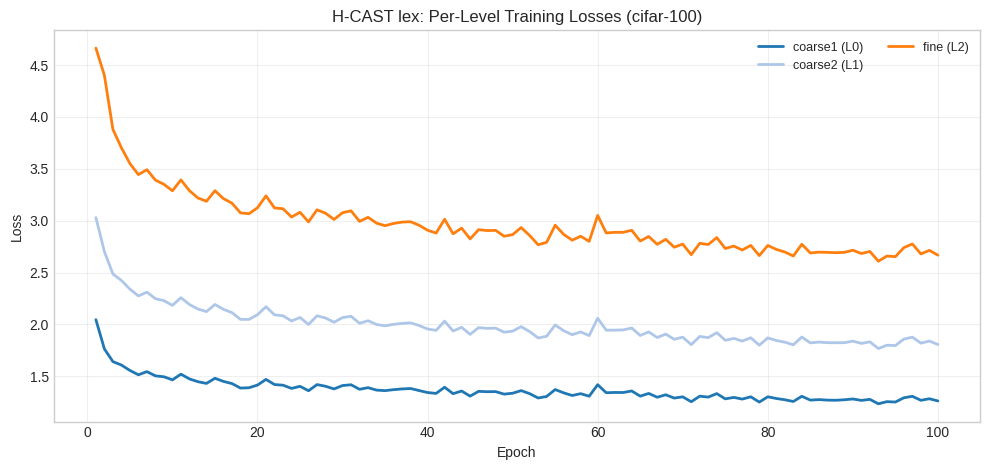

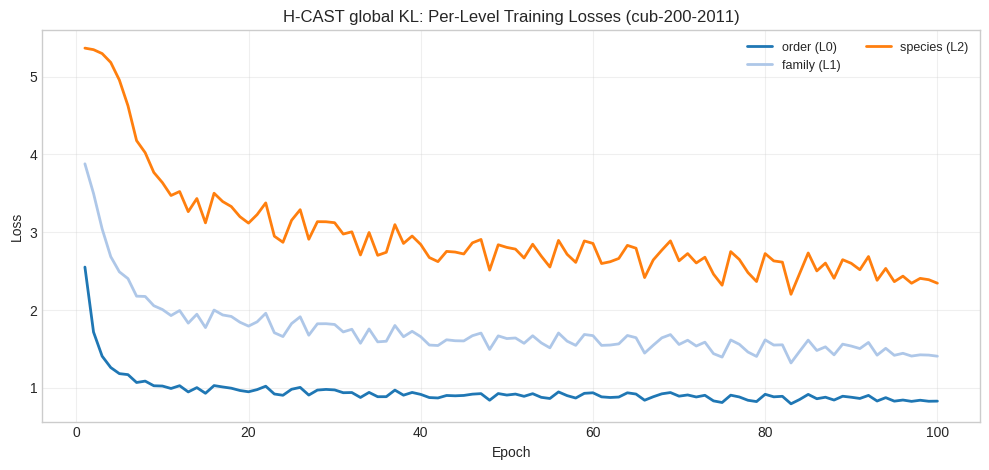

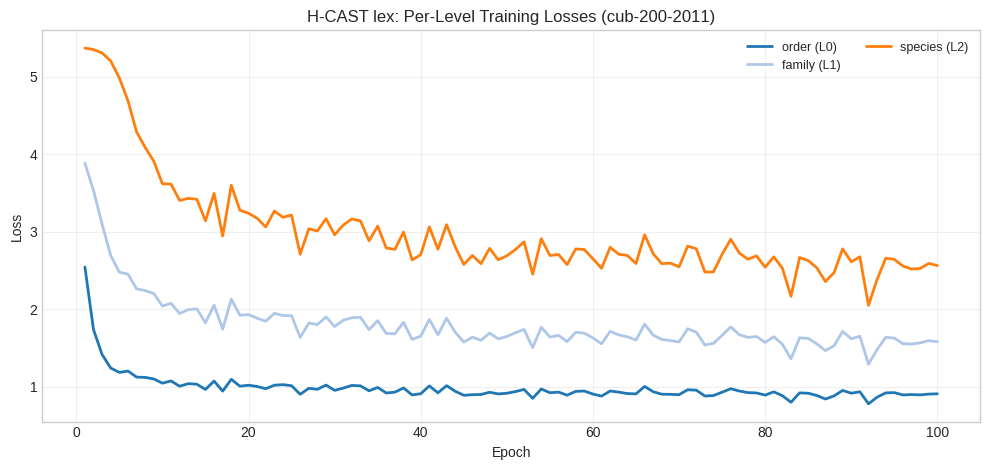

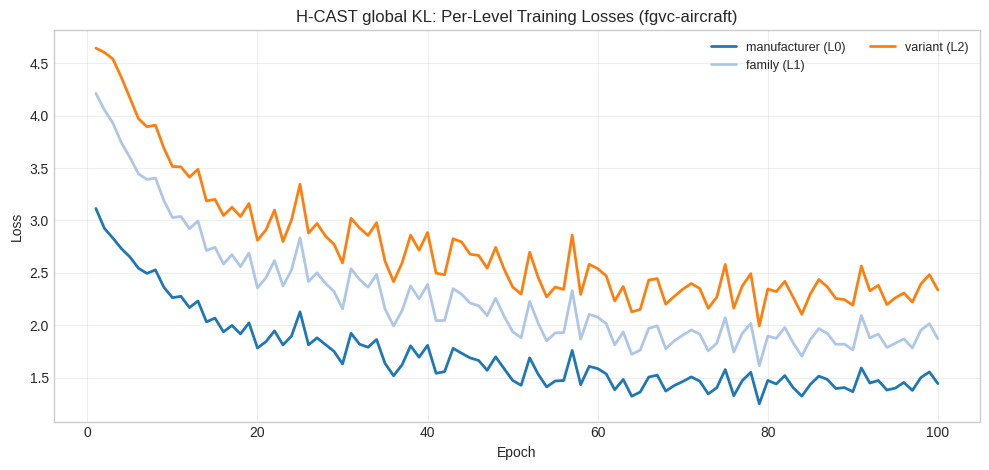

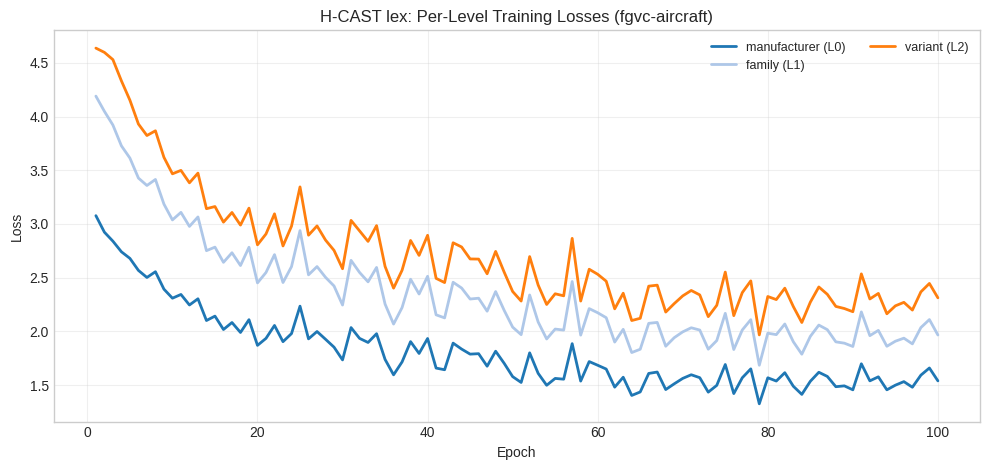

In [17]:
analysis.plot_per_run_per_level_training_losses()


## Gradient Diagnostics (Train)

This section visualizes trunk-based gradient/parameter metrics and lexicographic projection diagnostics stored in `train_metrics` for each epoch.

- Standard views are organized by subsets: `t3t2t1`, `t3`, `t2t1`, `t2`, and `t1`.
- Pre-gradient norms include:
  - `t3t2t1`: coarse
  - `t3`: coarse
  - `t2t1`: coarse, mid
  - `t2`: coarse, mid
  - `t1`: coarse, mid, fine
- Gradient cosines shown: `cos_mid_coarse`, `cos_fine_coarse`, `cos_fine_mid` (pairwise, trunk-agnostic overlaps).
- Parameter norms/movement are shown on the same trunk subsets (`t3t2t1/t3/t2t1/t2/t1`).
- In lex mode, `post_grad_*` mirrors pre-gradient keys and a dedicated pre-vs-post overlay is plotted.


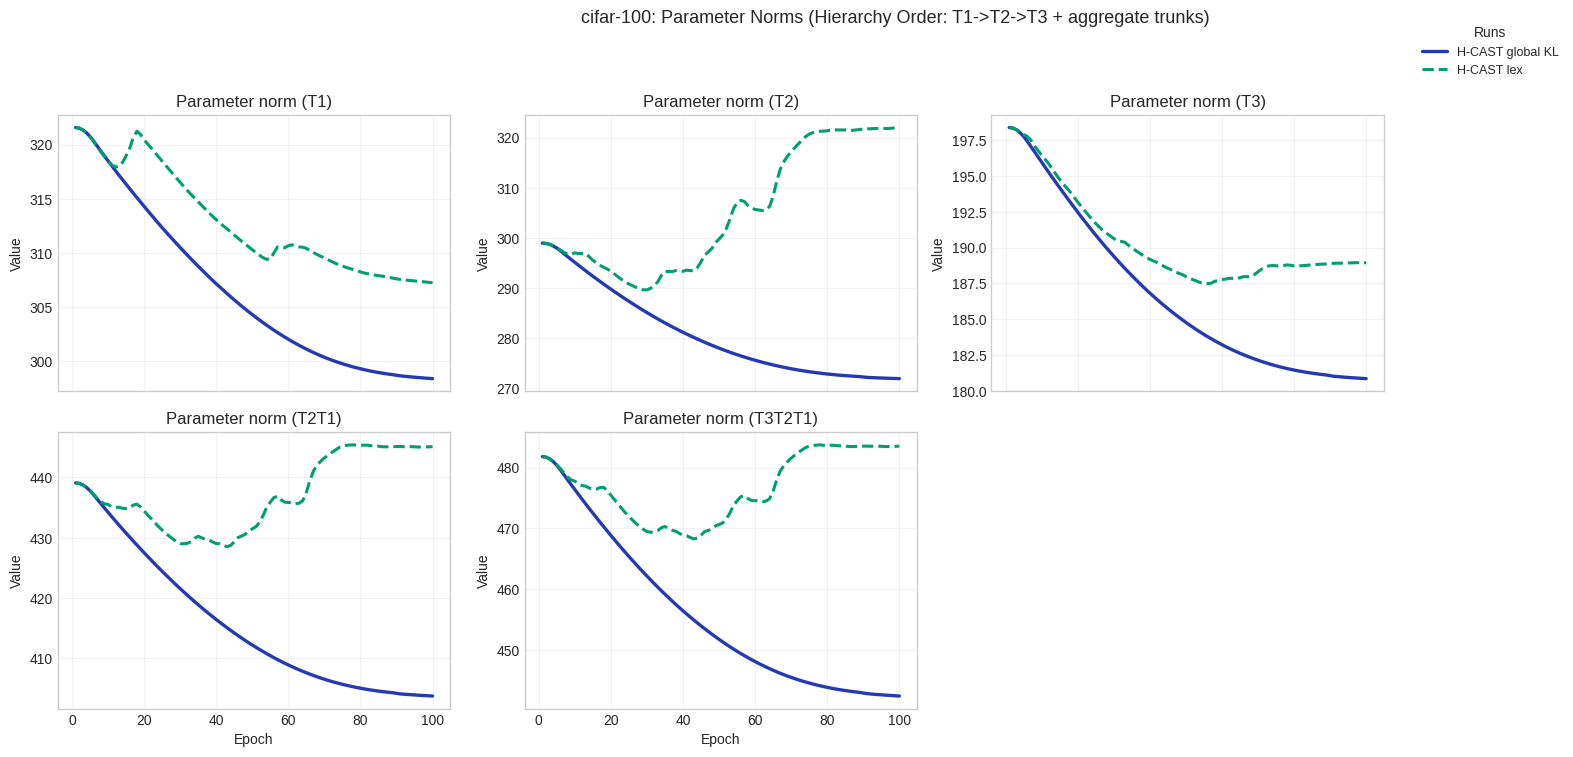

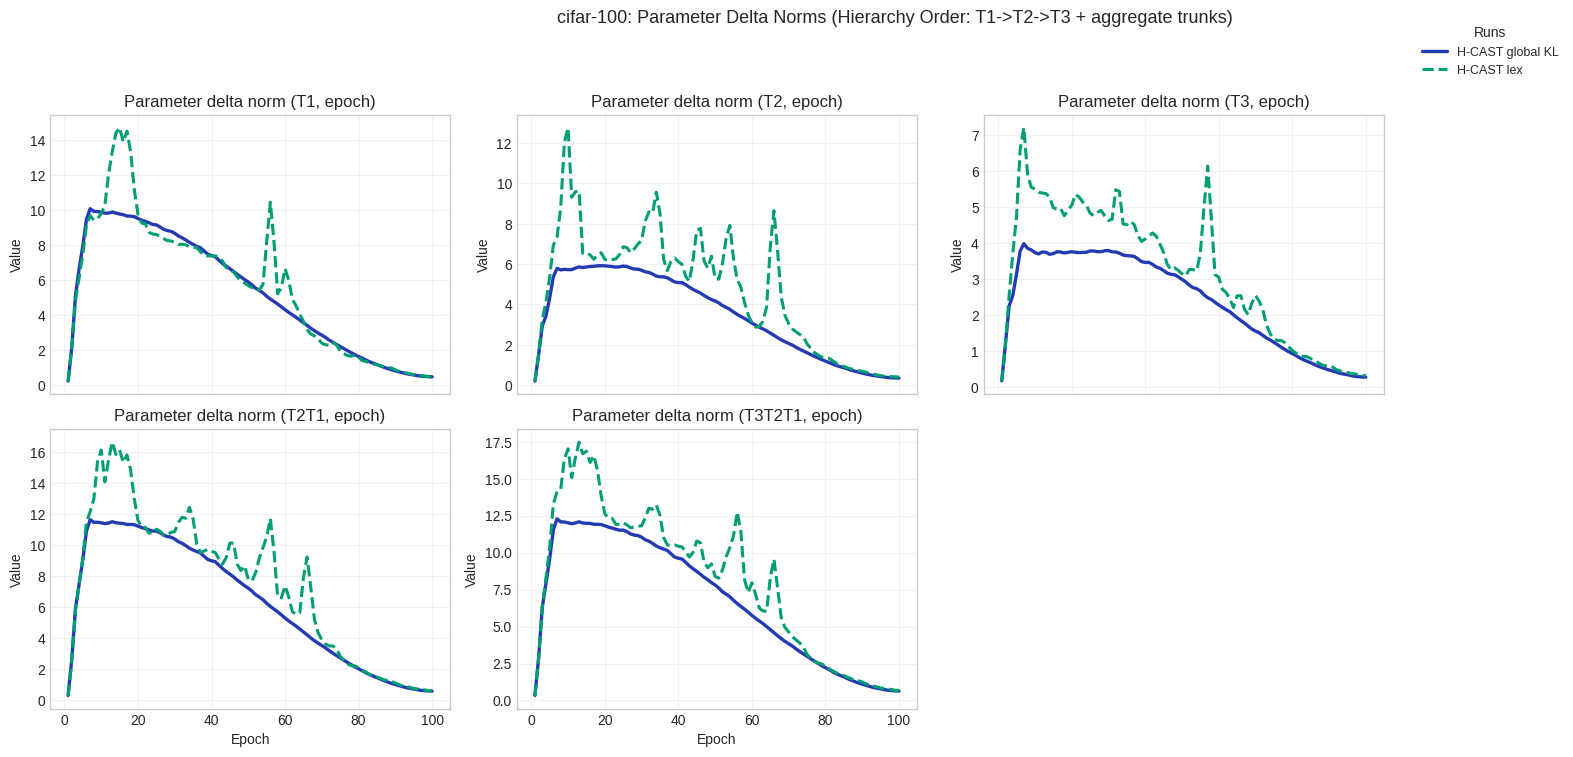

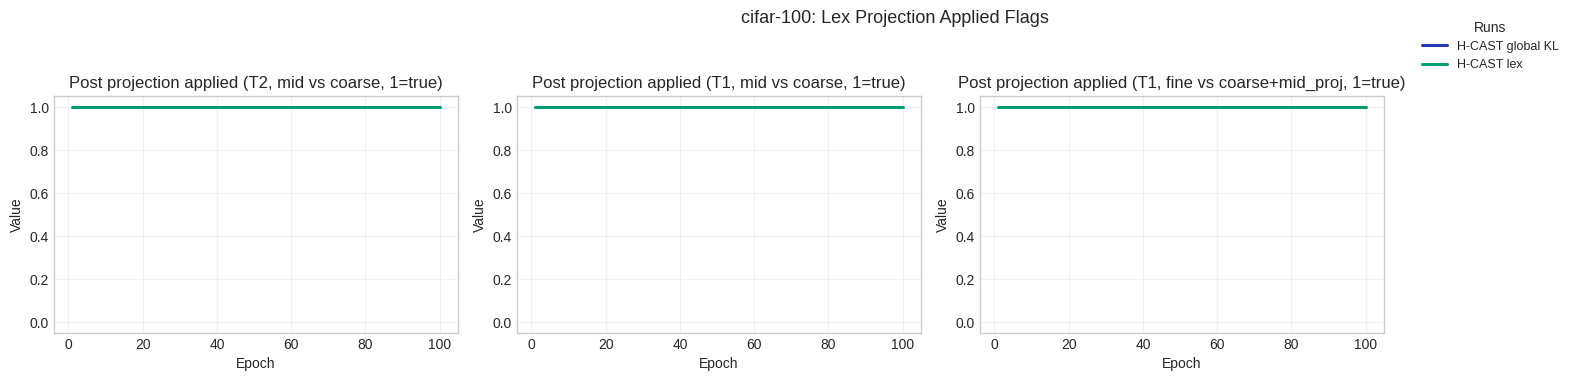

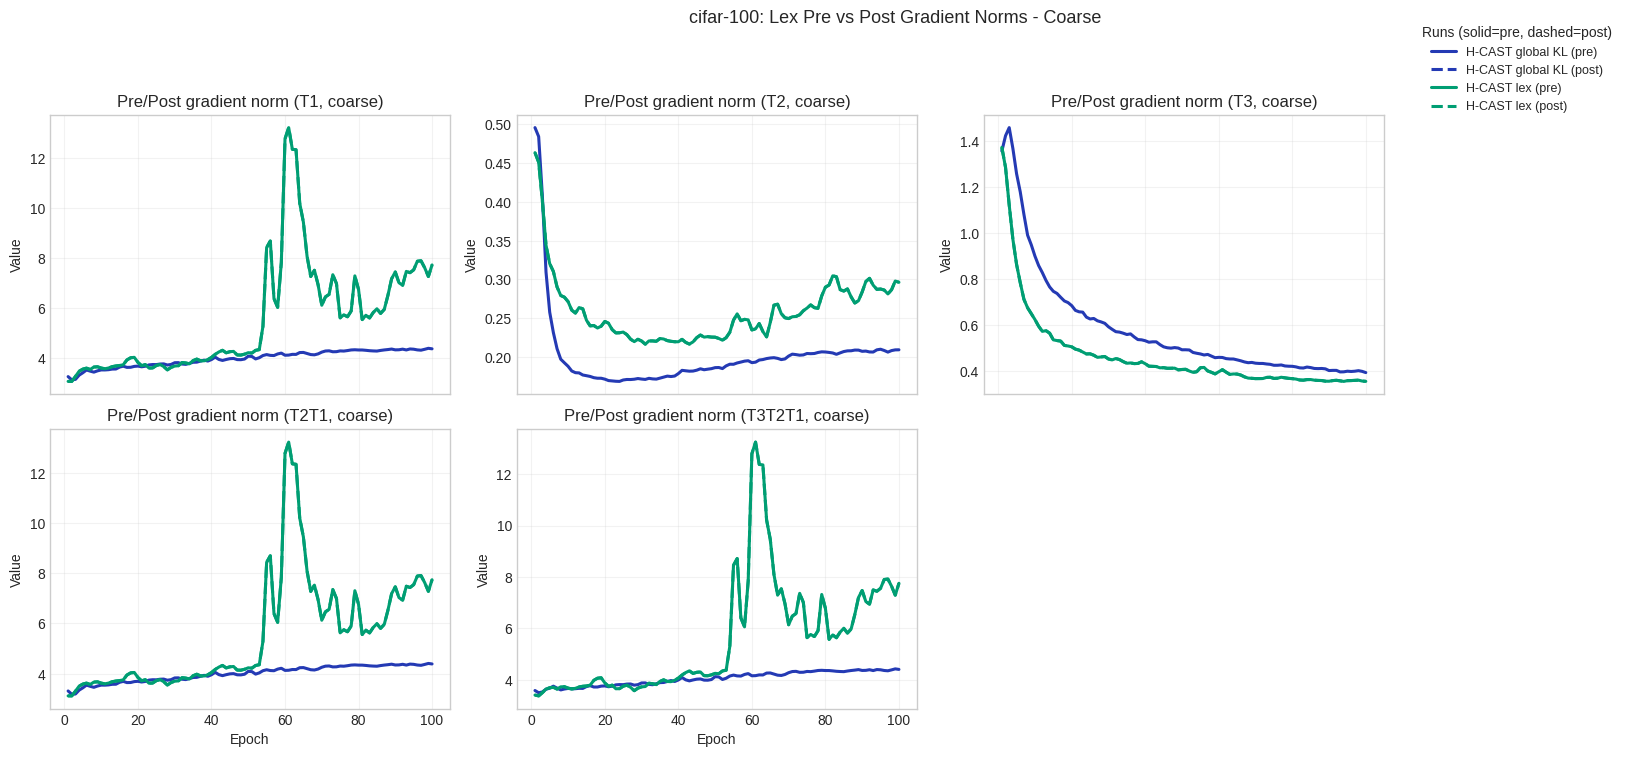

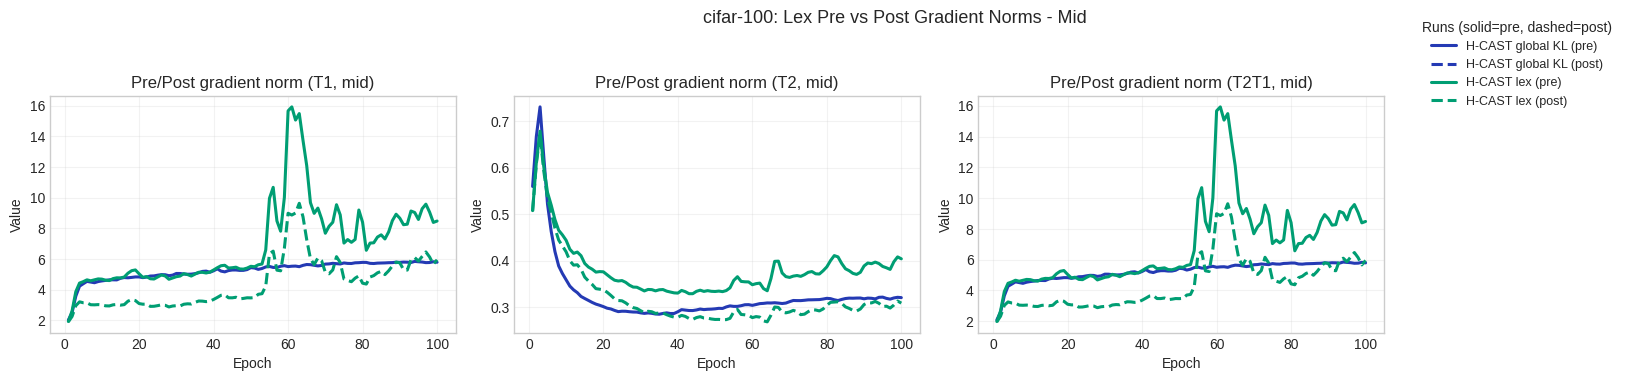

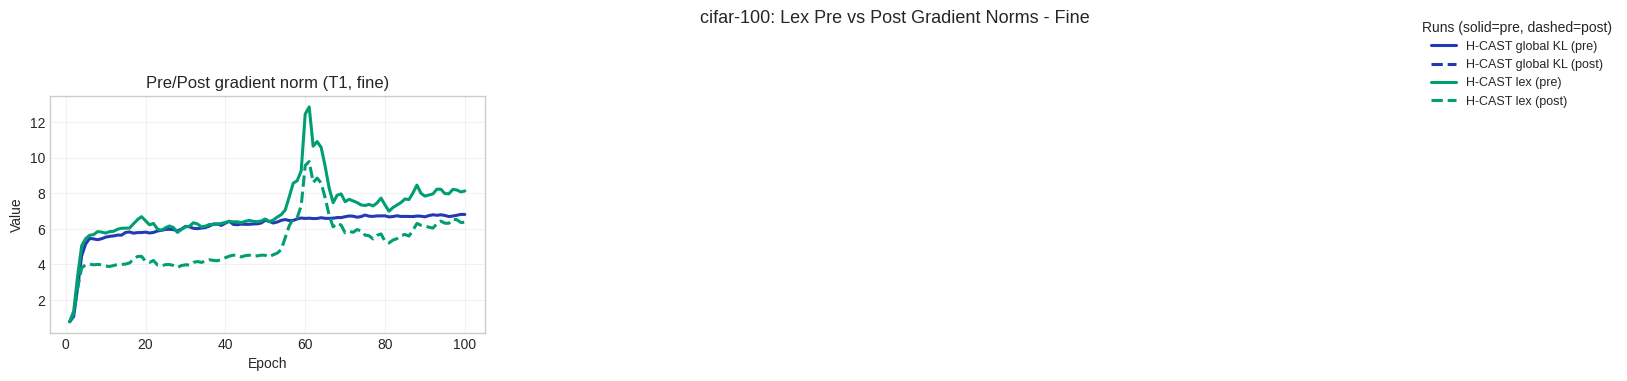

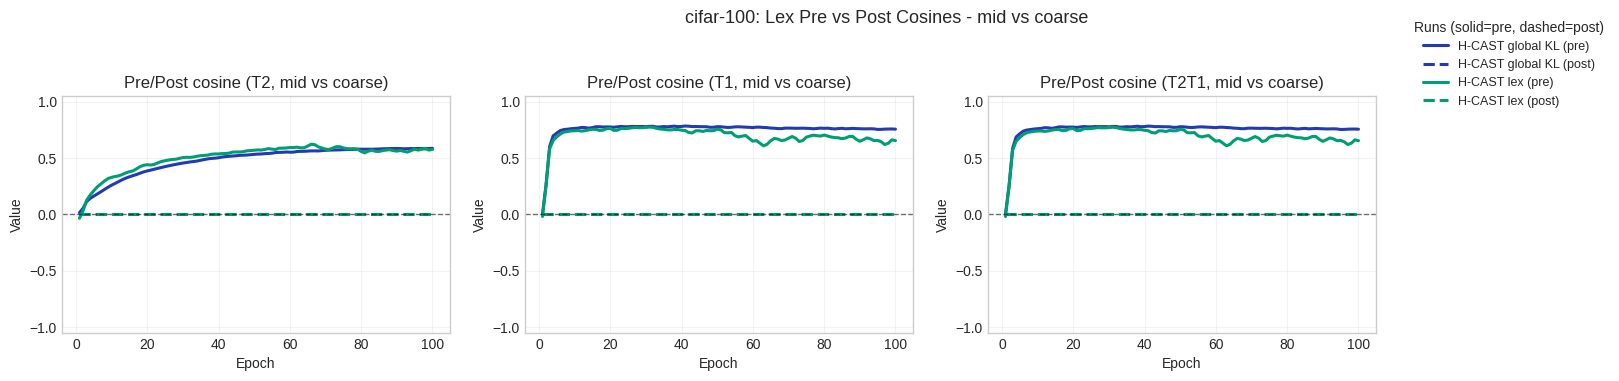

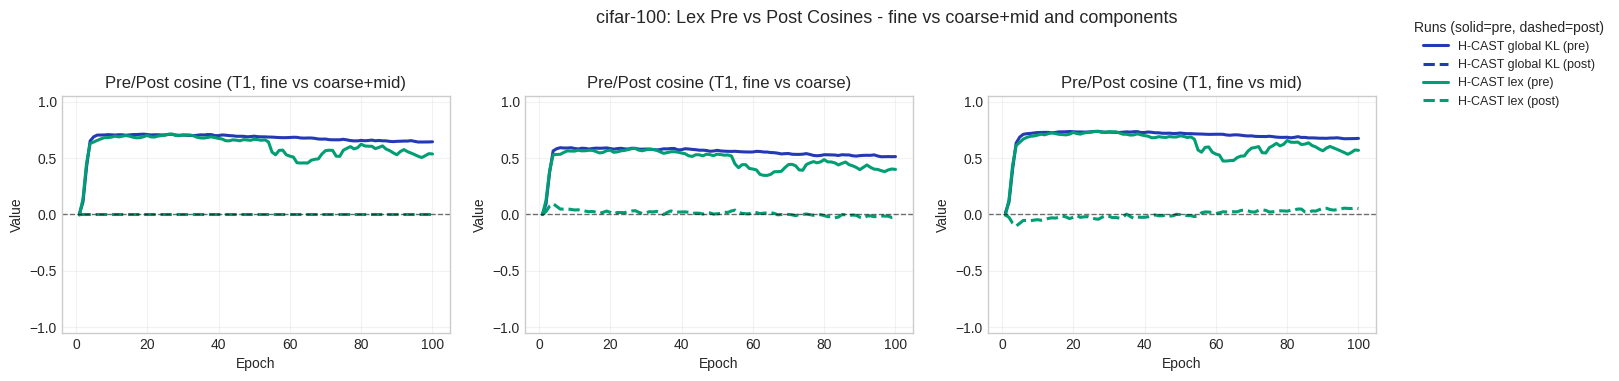

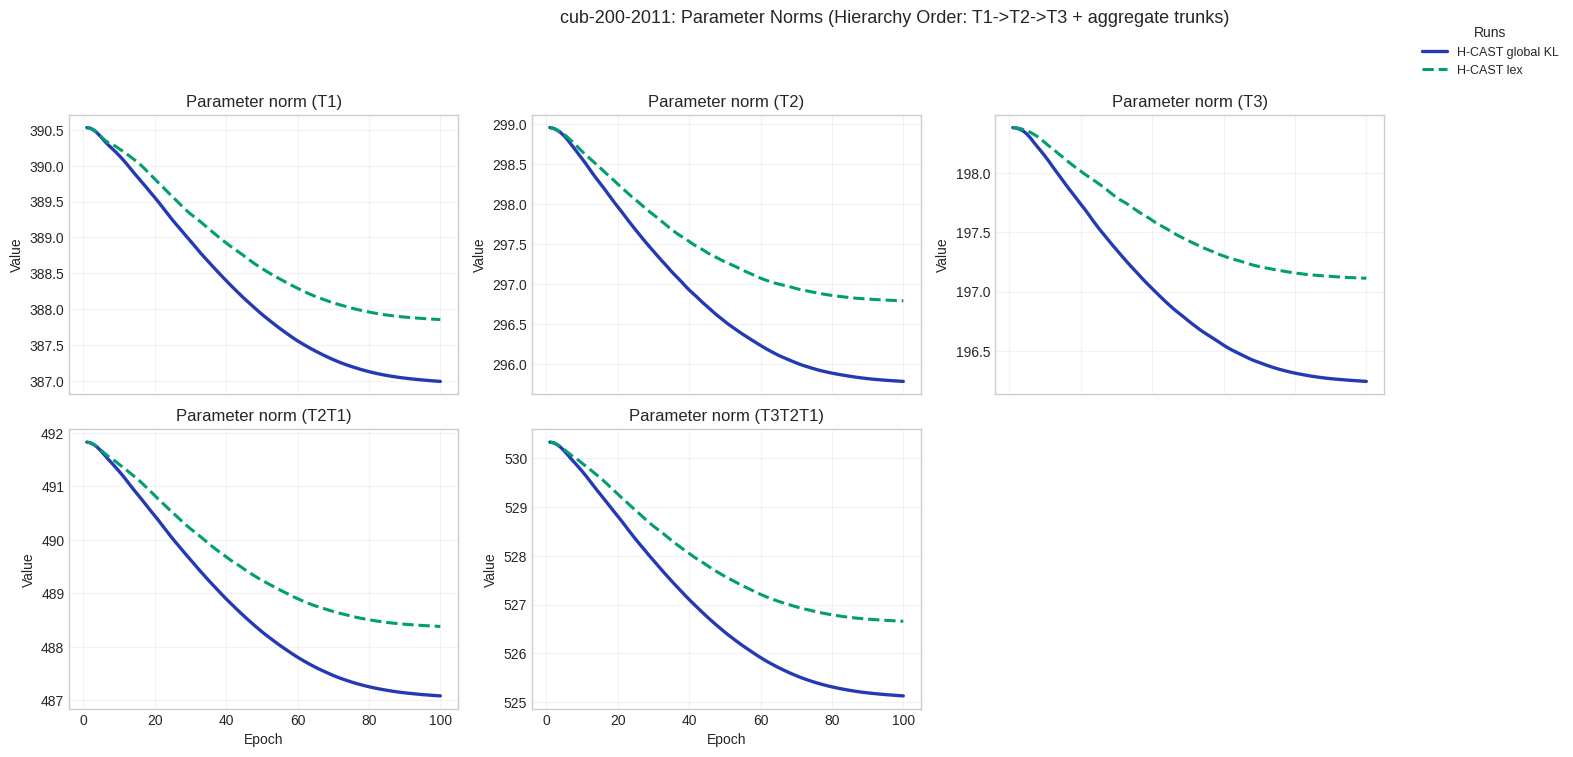

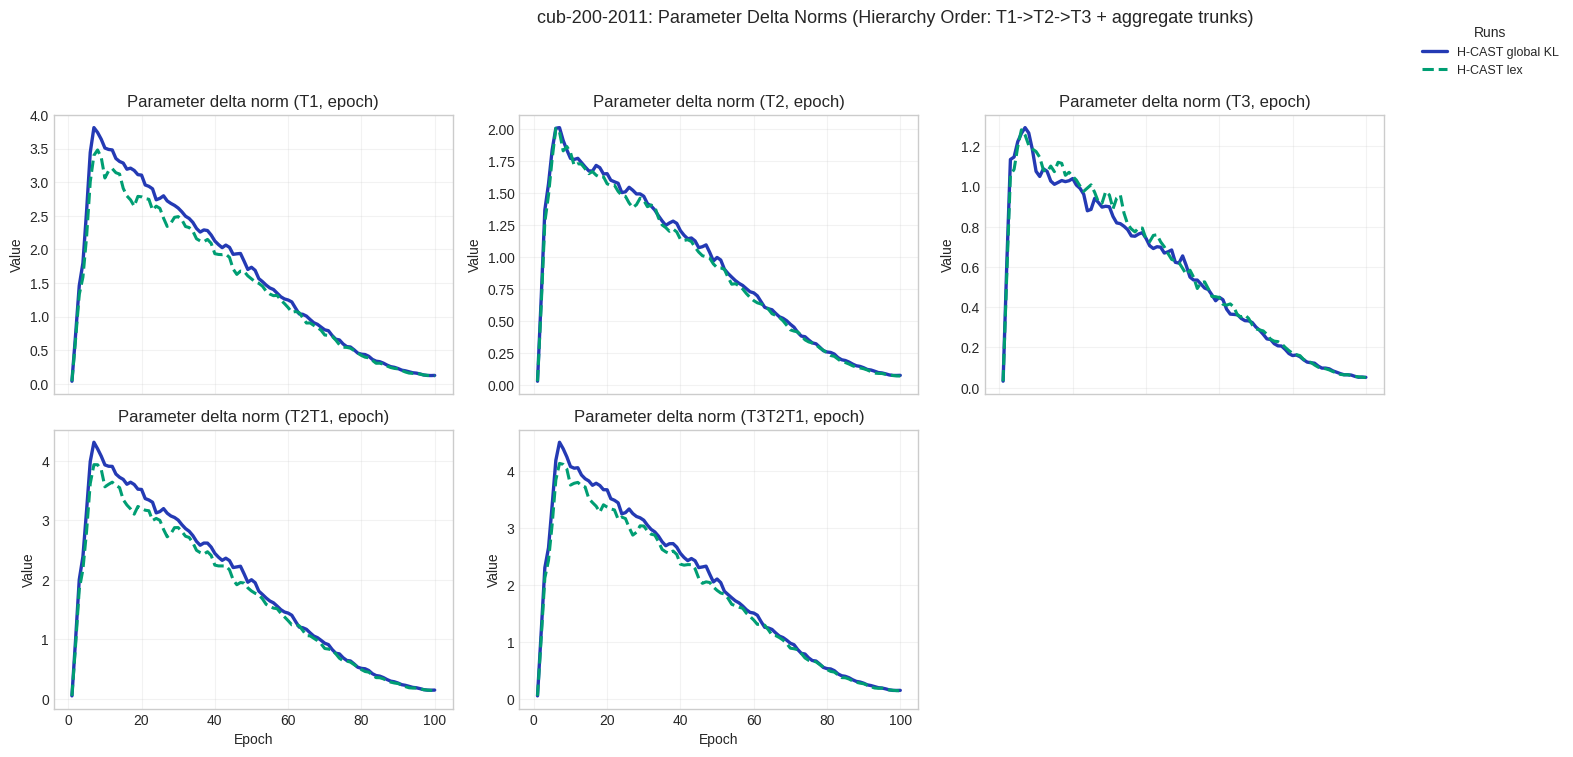

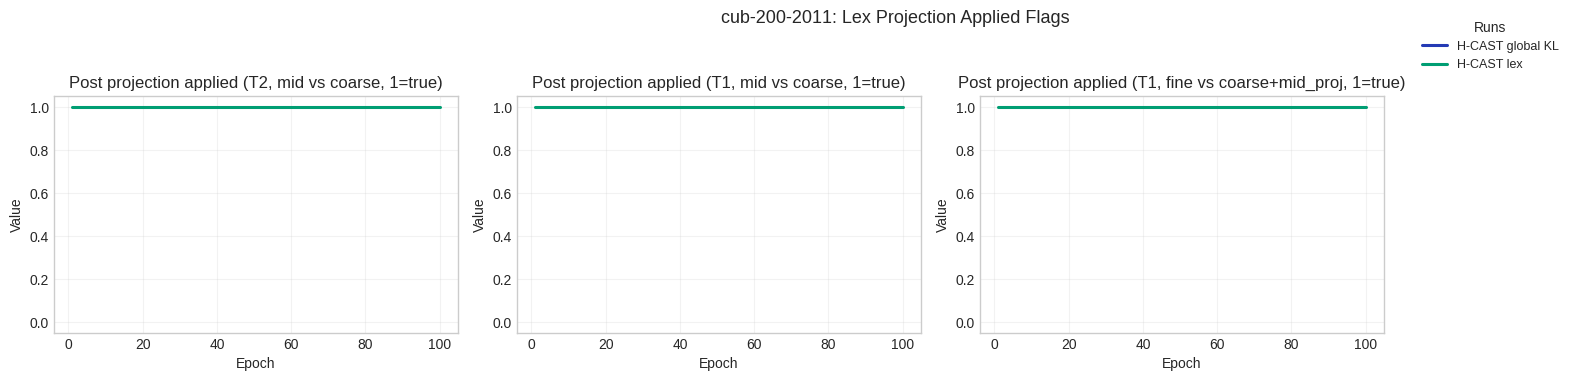

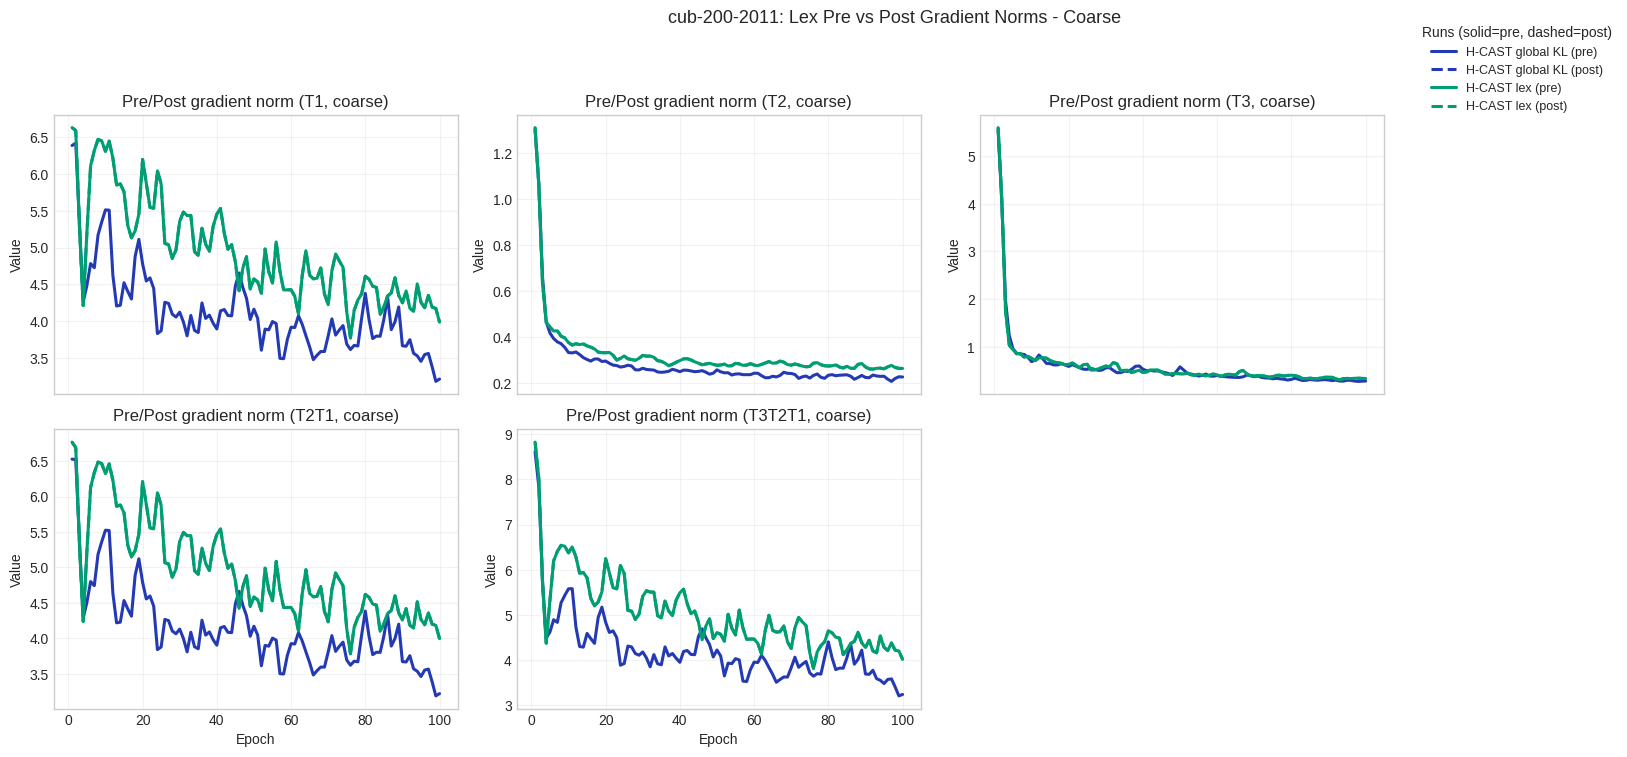

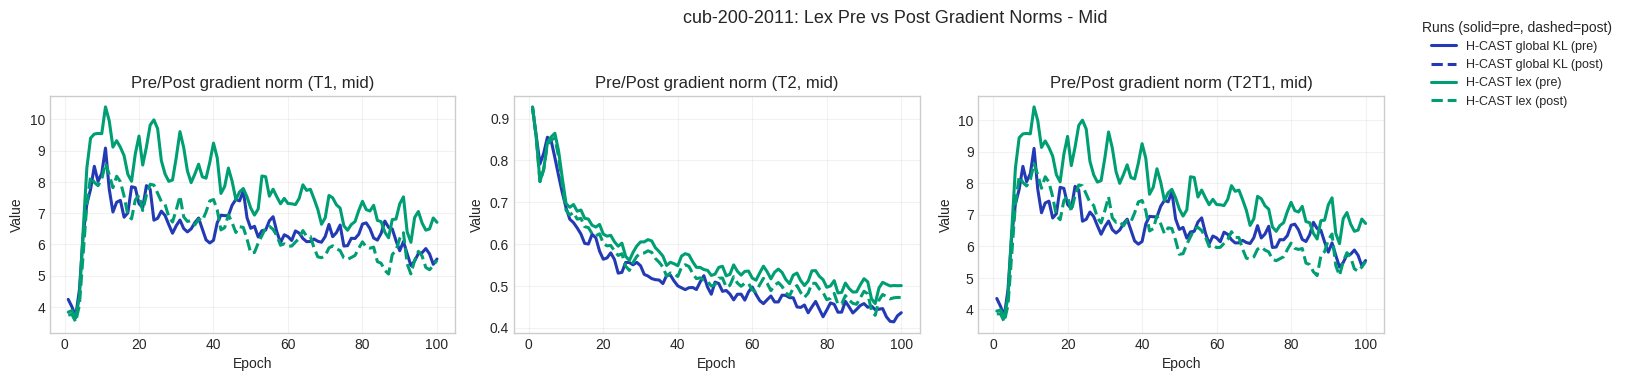

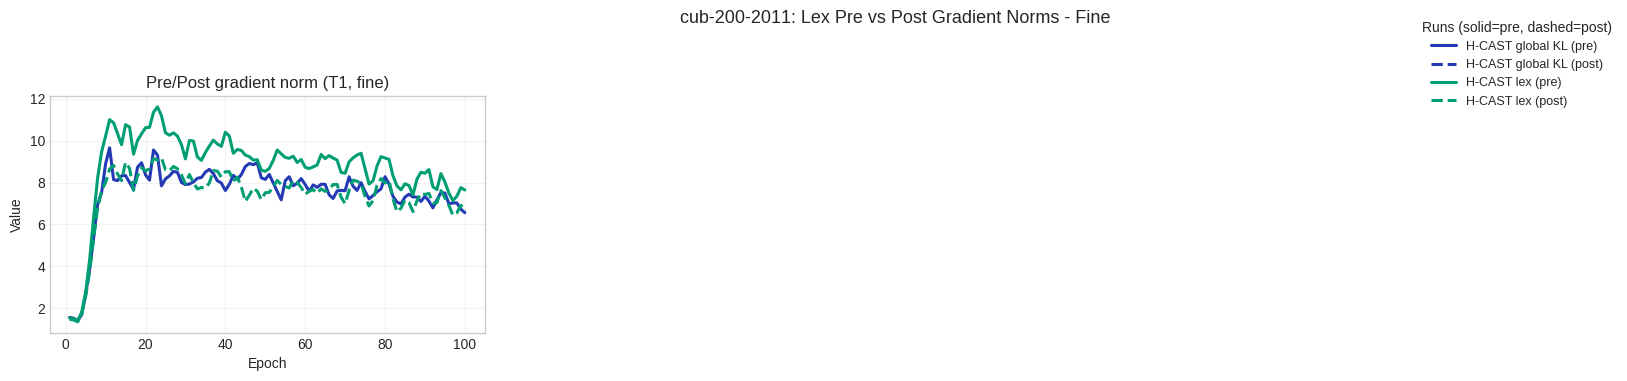

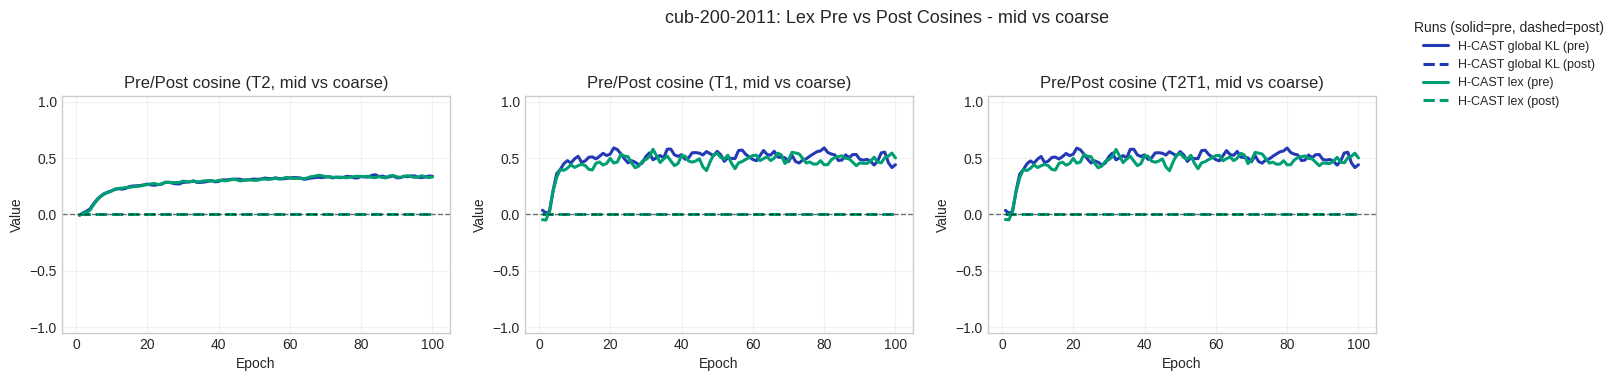

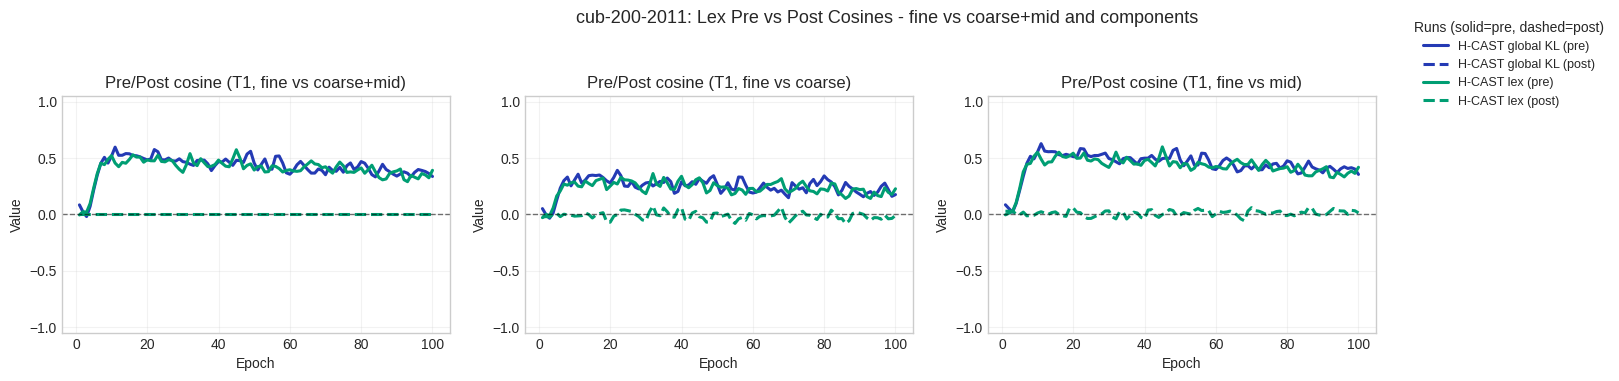

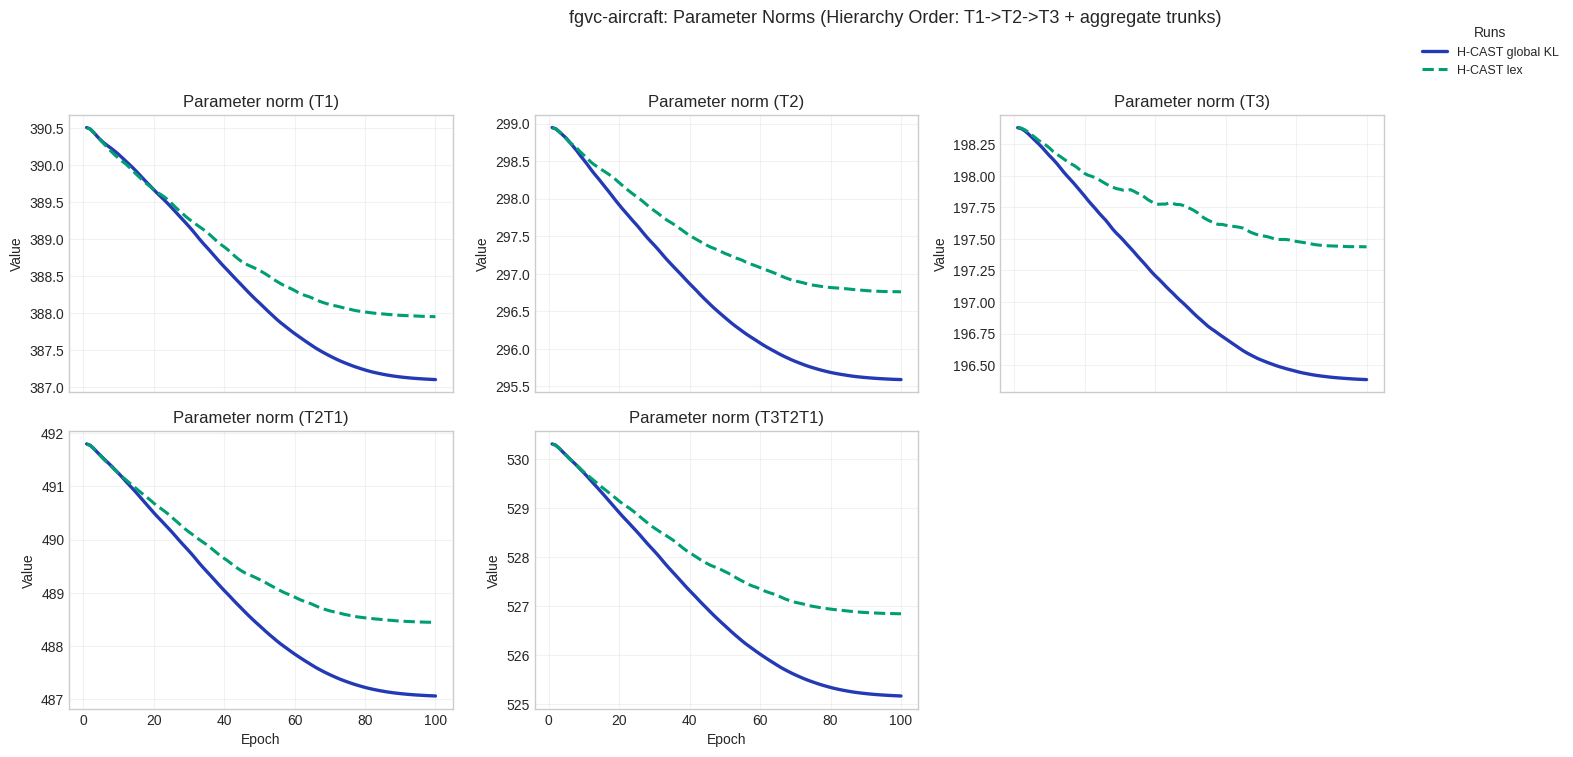

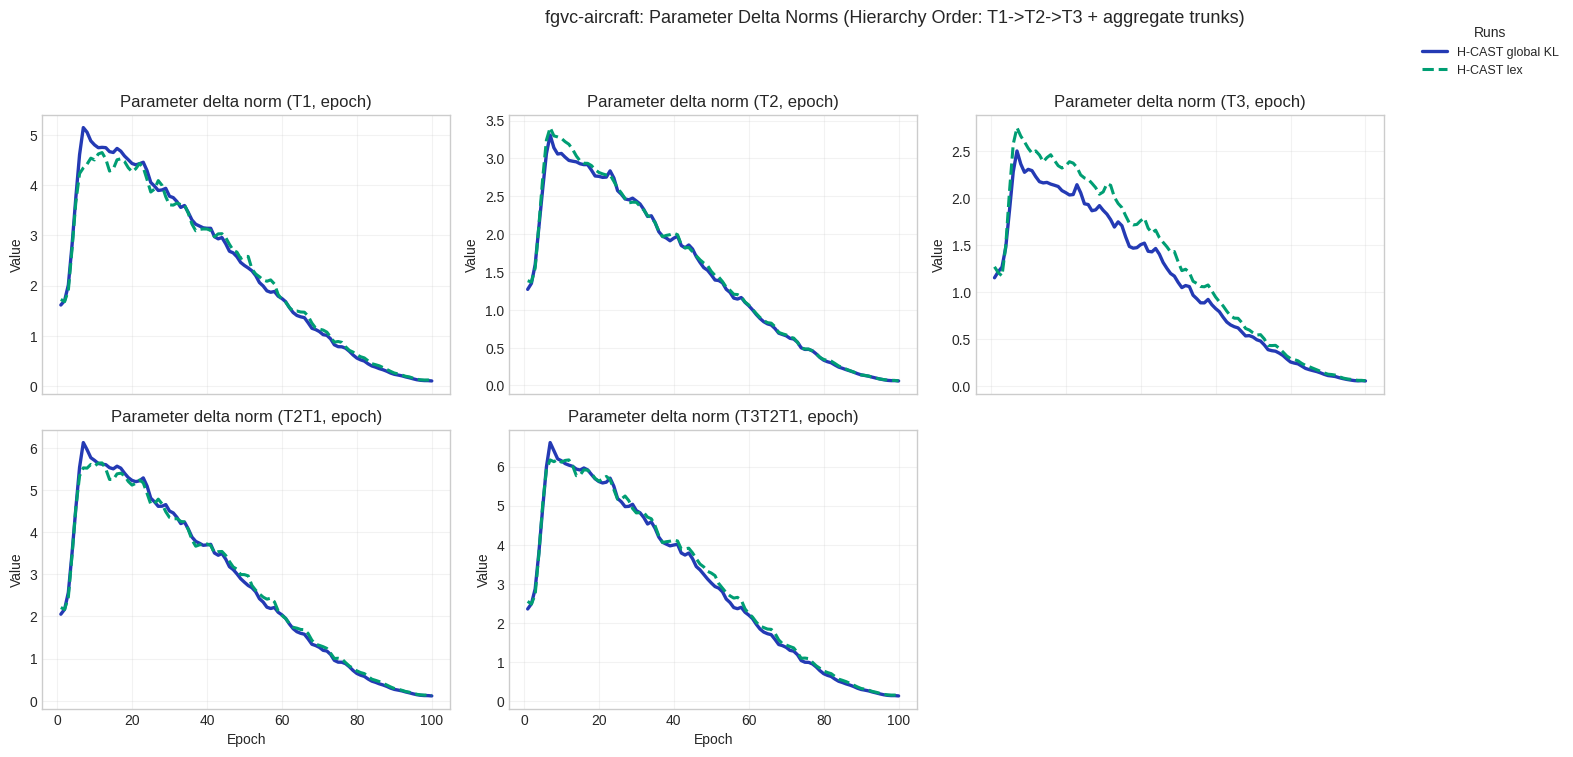

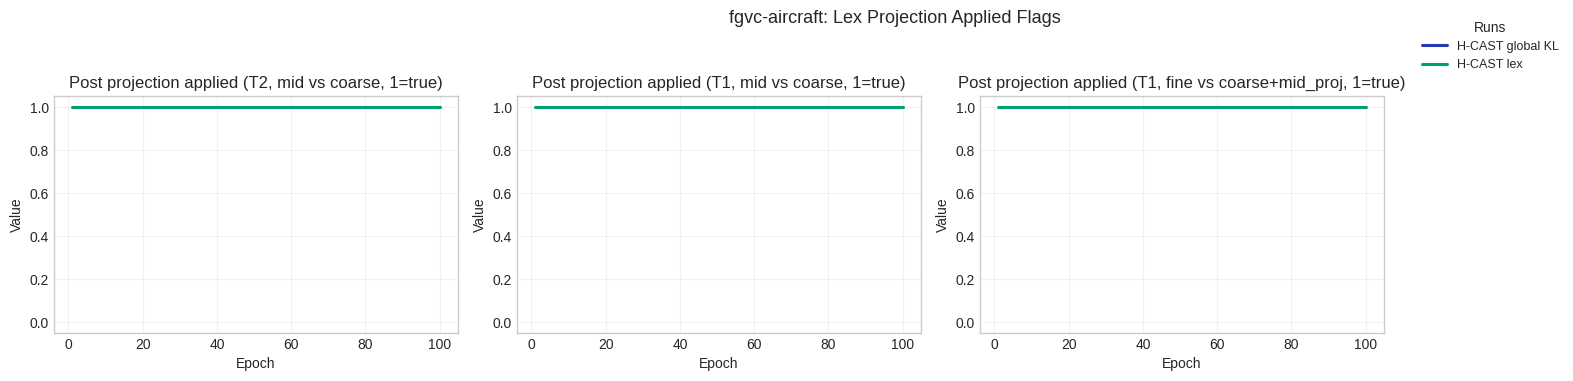

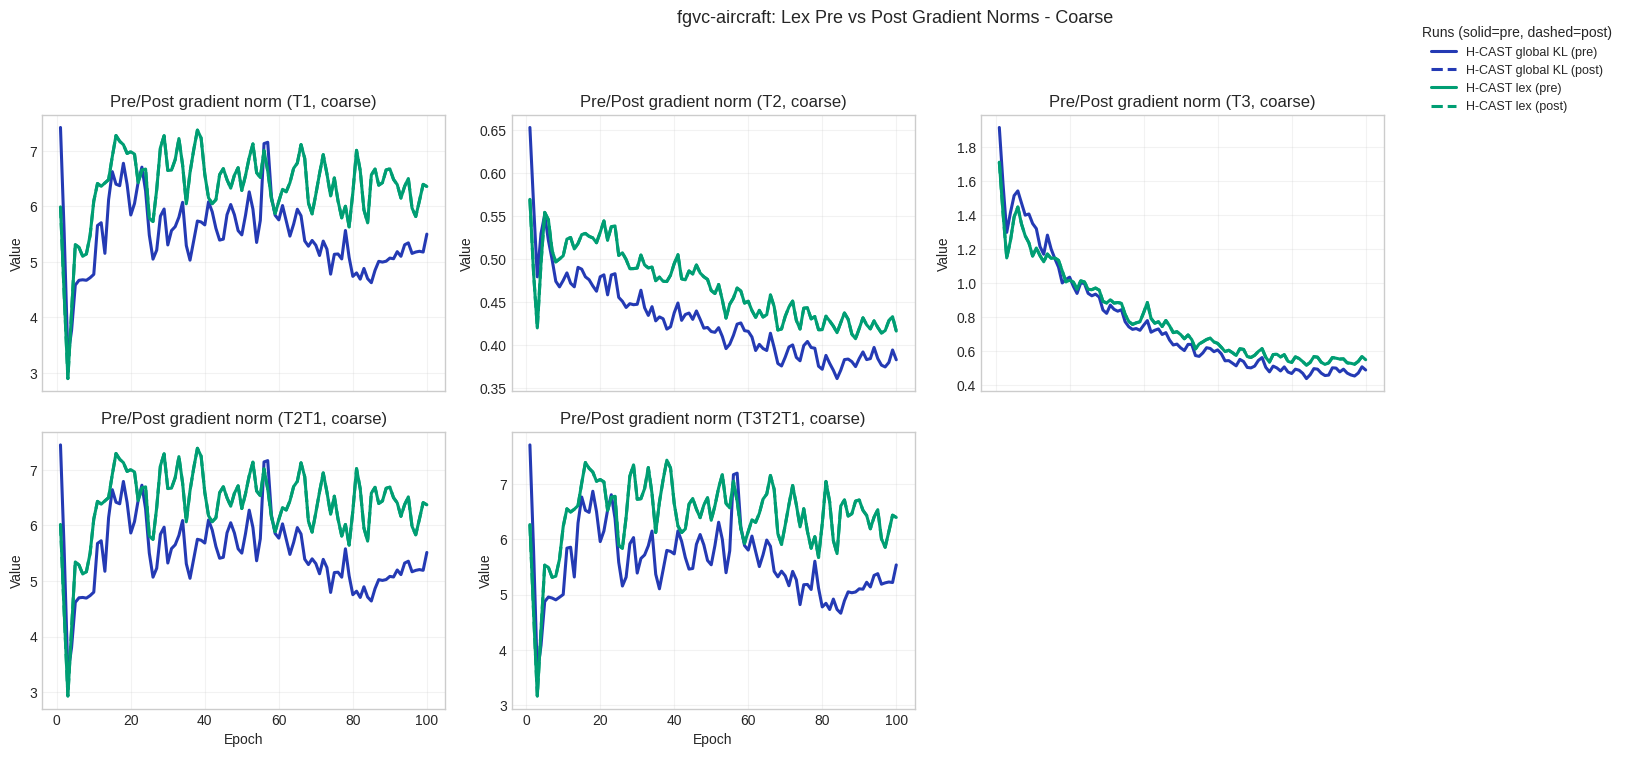

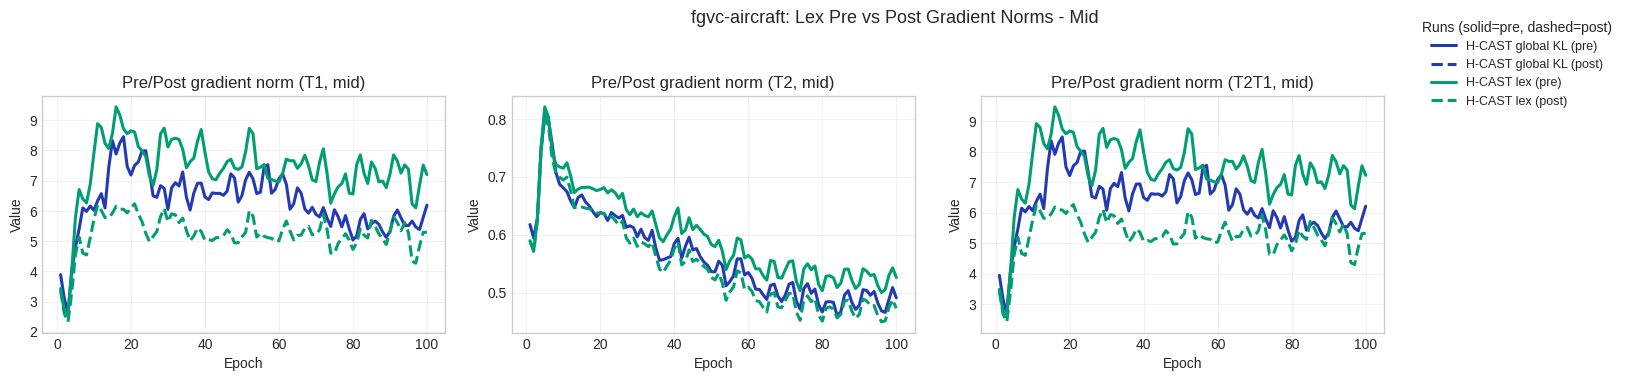

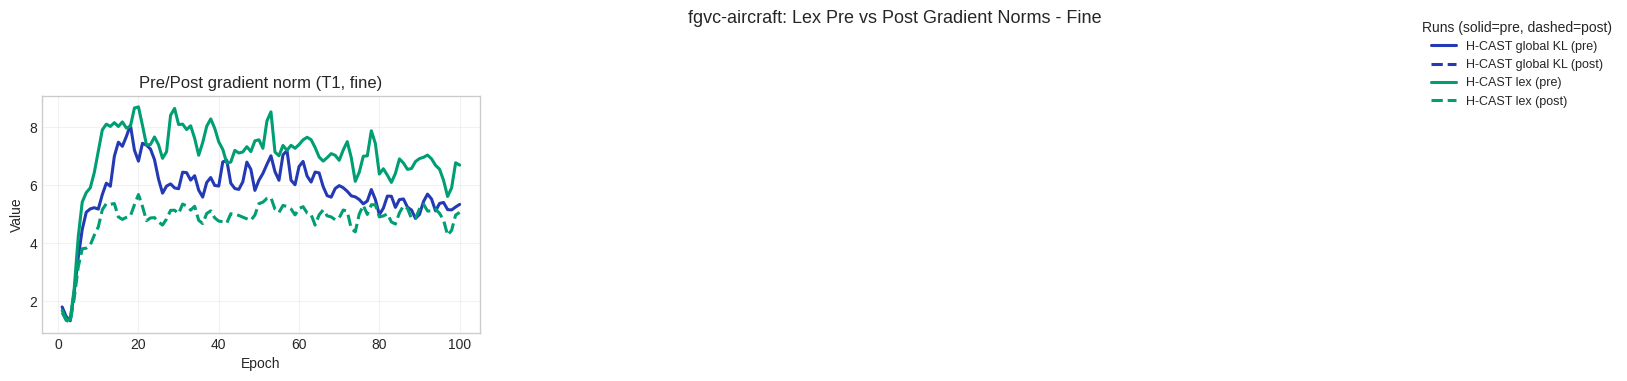

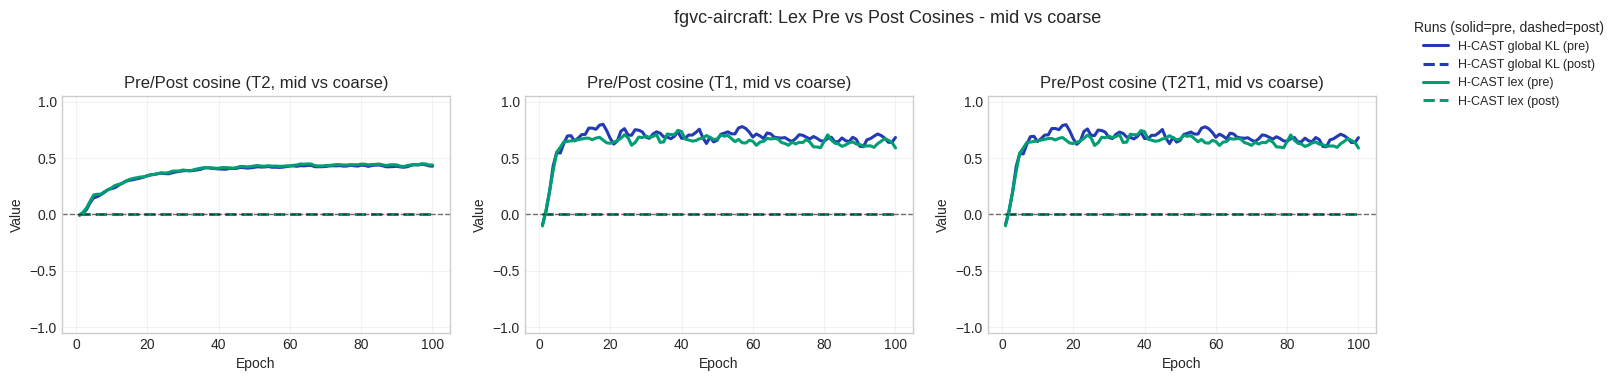

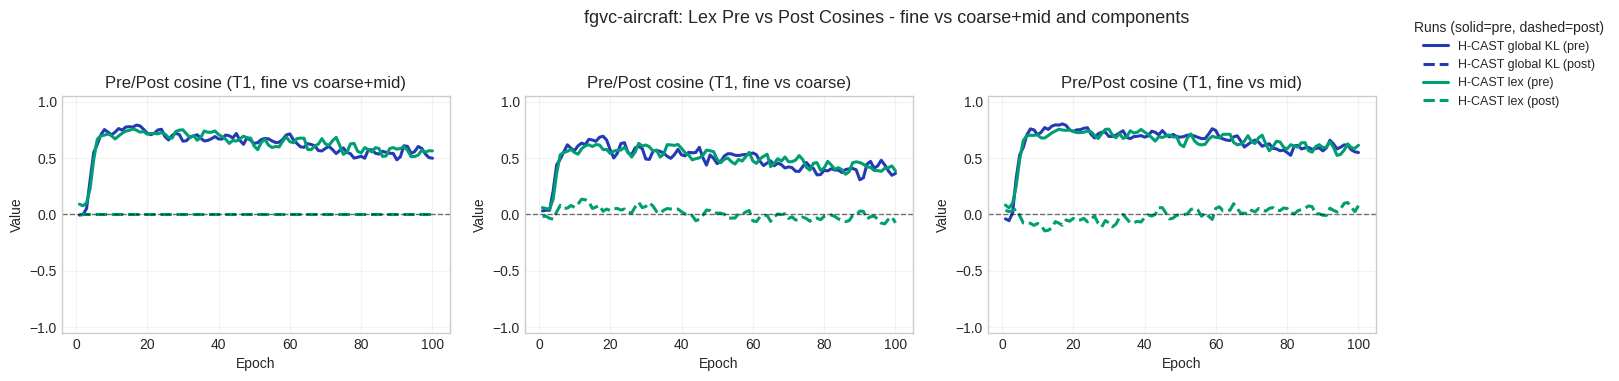

In [18]:
GRAD_SMOOTH_WINDOW = 2
SHOW_RAW_OVERLAY = False
RAW_ALPHA = 0.12
N_COLS = 3
LOG_SCALE_FOR_NORMS = False
AX_WIDTH = 6.0
AX_HEIGHT = 3.8
LEGEND_GUTTER_RATIO = 0.78
LEGEND_MAX_ROWS_PER_COL = 10

analysis.plot_gradient_diagnostics(
    smooth_window=GRAD_SMOOTH_WINDOW,
    show_raw_overlay=SHOW_RAW_OVERLAY,
    raw_alpha=RAW_ALPHA,
    n_cols=N_COLS,
    log_scale_for_norms=LOG_SCALE_FOR_NORMS,
    ax_width=AX_WIDTH,
    ax_height=AX_HEIGHT,
    legend_gutter_ratio=LEGEND_GUTTER_RATIO,
    legend_max_rows_per_col=LEGEND_MAX_ROWS_PER_COL,
)


Interpretation note:

- Large spikes in gradient norms indicate unstable update pressure for that subset/level path.
- If `grad_norm_t1_fine` collapses while `t1` coarse/mid stay high, fine supervision is not effectively reaching shared parameters.
- Negative cosine values indicate level conflict on the corresponding subset.
- `param_norm_*` is scale, `delta_param_norm_*` is per-epoch movement.
- In lex mode, projected cosines should move near 0 (orthogonality on the target mask).
- `post_projection_applied_* = 0` means the corresponding projection step was skipped for numerical safety.


## Per-Level Validation Accuracy (Top-Down and Independent)

Each level plot overlays both modes on the same axes:
- color = run
- line style = mode (`topdown` solid, `independent` dashed).

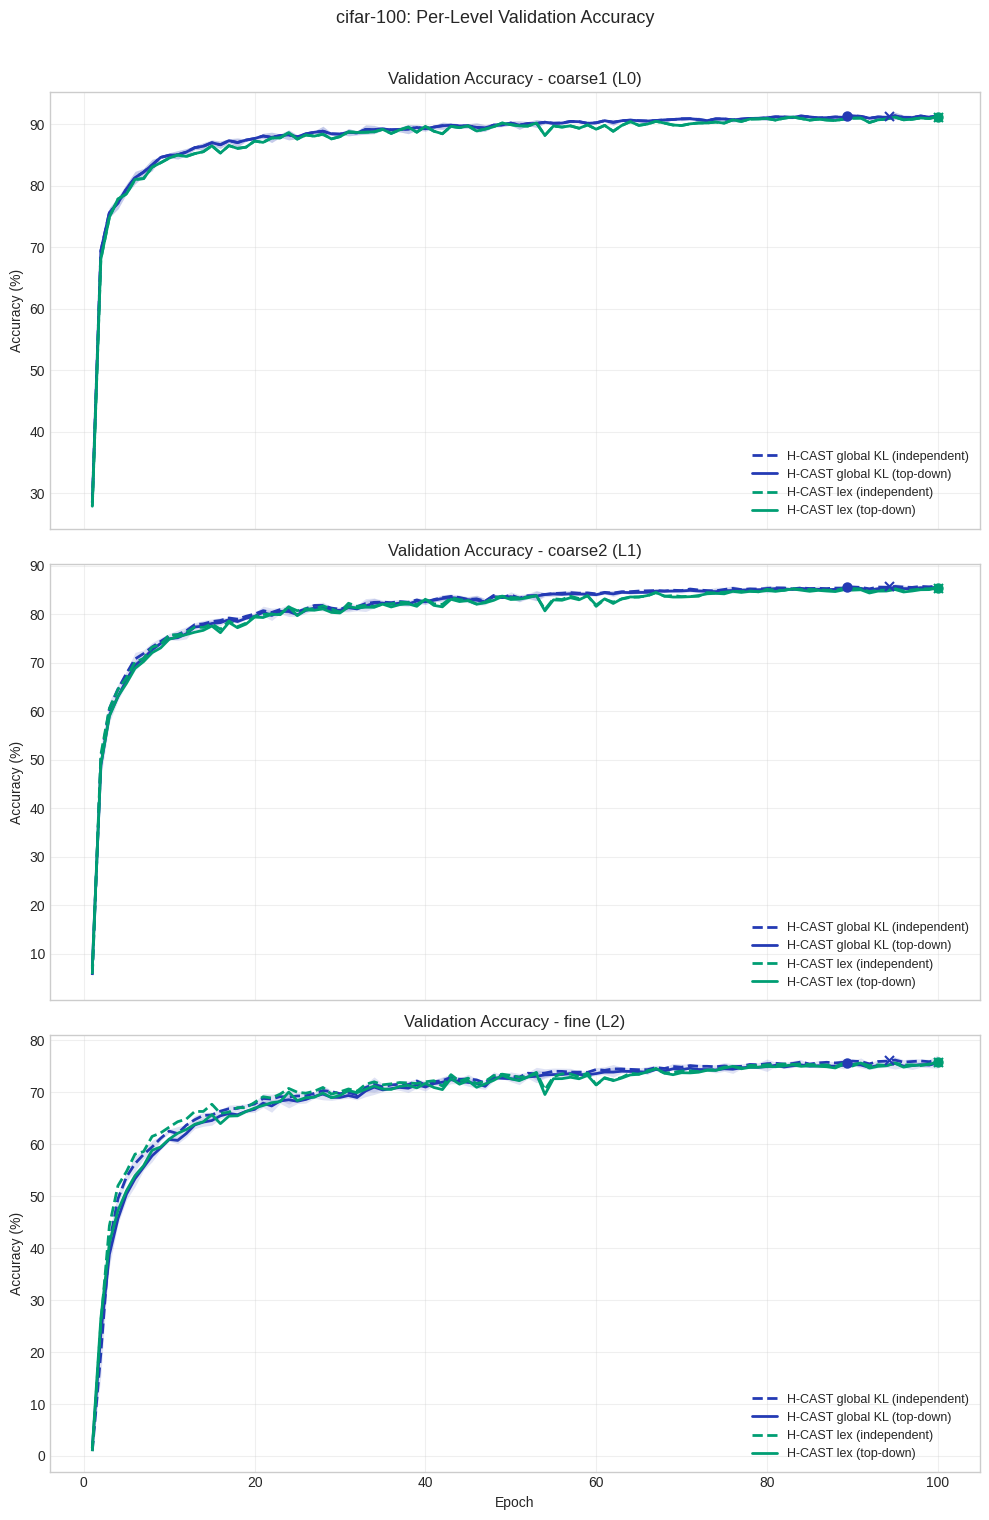

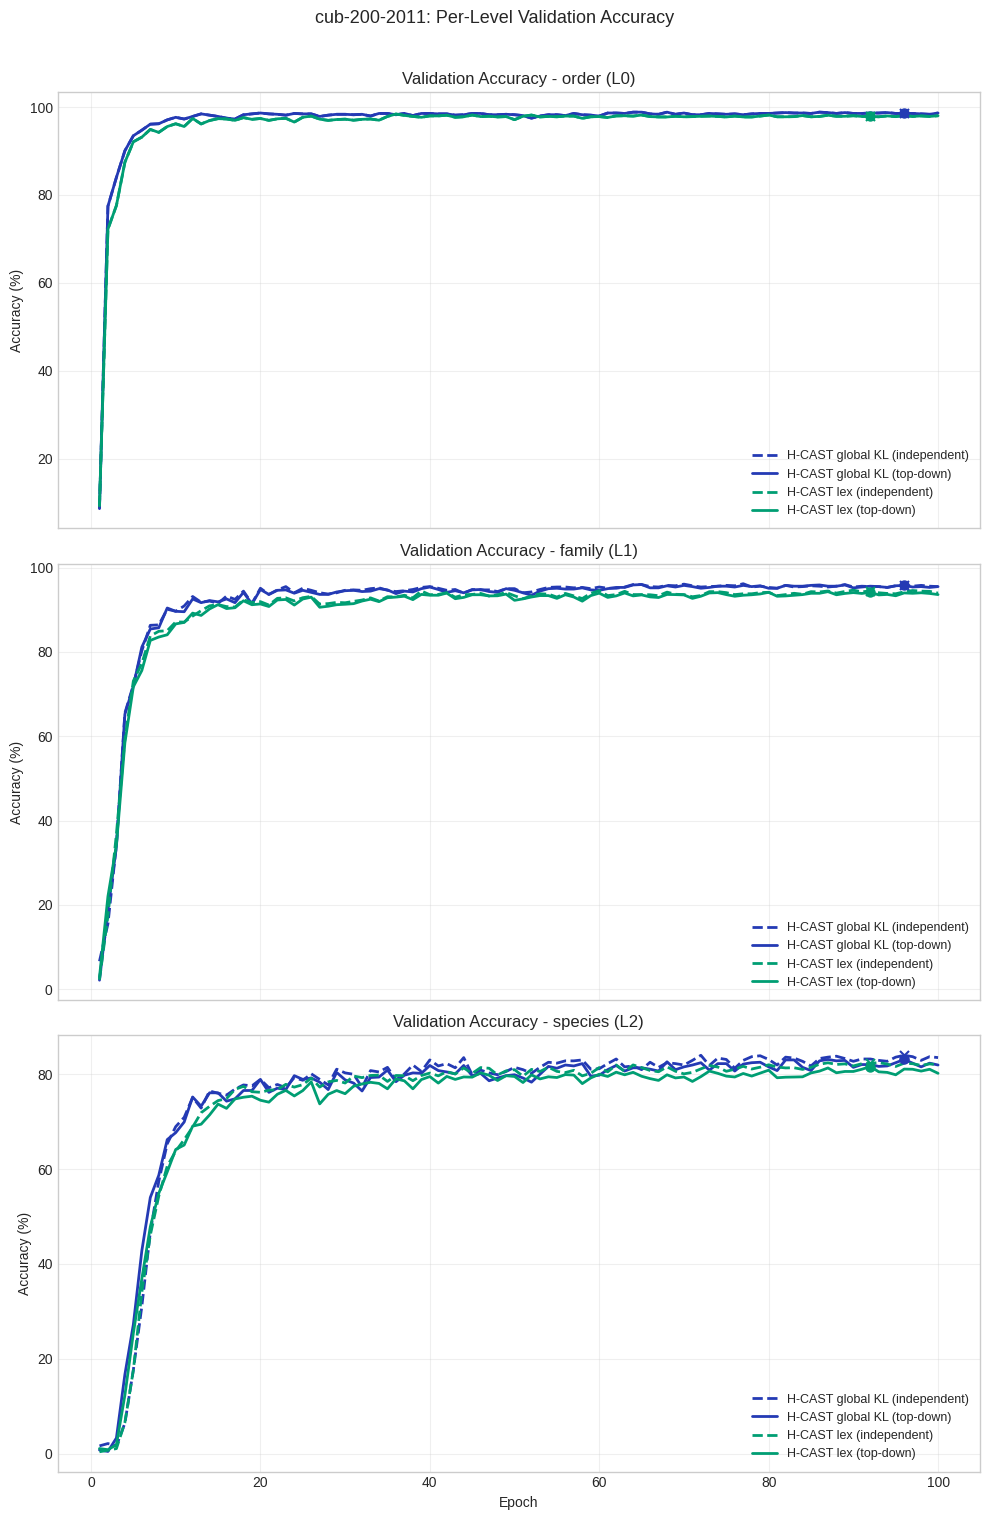

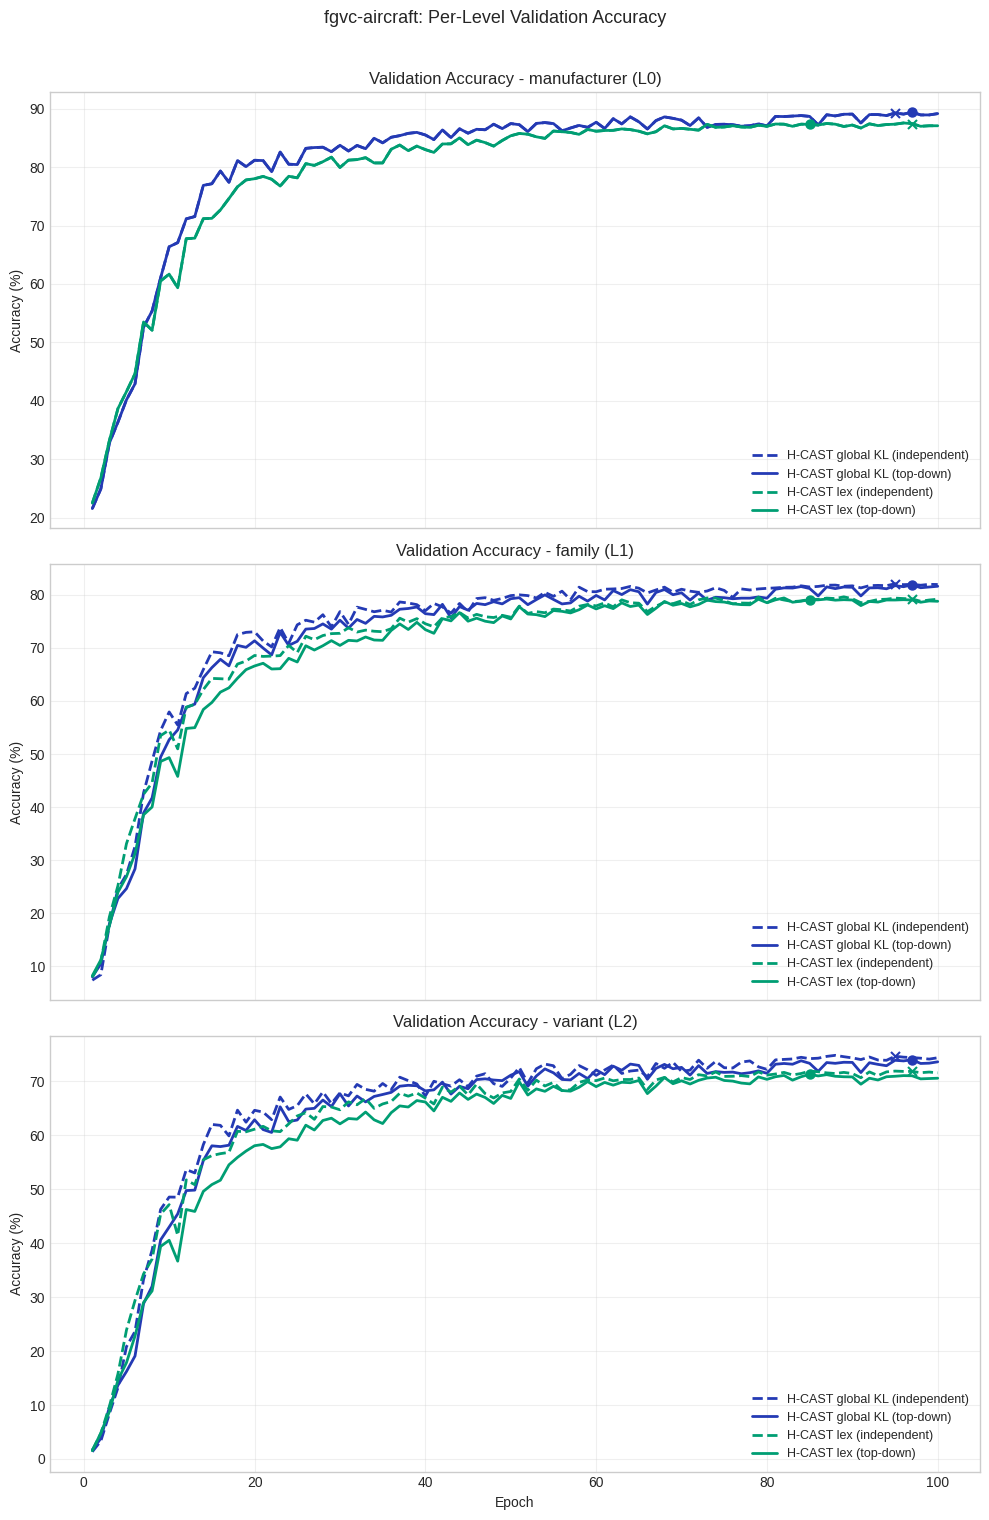

In [19]:
analysis.plot_per_level_validation_accuracy()


Interpretation note:
- In each subplot, solid vs dashed of the same color gives the top-down penalty/gain for that run.
- Across colors, you can compare runs within the same decoding mode by matching line style.
- Larger gaps at deeper levels usually have the strongest impact on final path metrics.

## Final Test Comparison Table

For each dataset, the table compares key test metrics for selected runs and reports deltas versus the first run listed for that dataset.

In [20]:
analysis.show_final_test_tables()


### Dataset: `cifar-100`
Baseline run: **H-CAST global KL**

| Metric | H-CAST global KL (n=3) | H-CAST lex (n=1) |
|---|---:|---:|
| Best epoch (TD/Ind) | 90.5 ± 13.4/98.0 ± 2.8 | 100/100 |
| FPA independent ↑ | <u>73.52% ± 0.25%</u> | **73.89% (+0.37 pp)** |
| FPA top-down ↑ | <u>75.01% ± 0.25%</u> | **75.23% (+0.22 pp)** |
| wAP independent ↑ | **78.32% ± 0.20%** | <u>77.99% (-0.33 pp)</u> |
| wAP top-down ↑ | <u>77.58% ± 0.22%</u> | **77.74% (+0.16 pp)** |
| TICE independent ↓ | <u>7.48% ± 0.25%</u> | **5.66% (-1.82 pp)** |
| TICE top-down ↓ | **0.00% ± 0.00%** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | **0.506 ± 0.004** | <u>0.508 (+0.002)</u> |
| AHD top-down ↓ | **0.490 ± 0.005** | <u>0.490 (+0.000)</u> |
| Acc independent coarse1 (L0) ↑ | **91.00% ± 0.11%** | <u>90.66% (-0.34 pp)</u> |
| Acc top-down coarse1 (L0) ↑ | **90.88% ± 0.06%** | <u>90.66% (-0.22 pp)</u> |
| Acc independent coarse2 (L1) ↑ | **85.43% ± 0.01%** | <u>84.97% (-0.46 pp)</u> |
| Acc top-down coarse2 (L1) ↑ | **85.10% ± 0.14%** | <u>85.07% (-0.03 pp)</u> |
| Acc independent fine (L2) ↑ | **75.89% ± 0.25%** | <u>75.59% (-0.30 pp)</u> |
| Acc top-down fine (L2) ↑ | <u>75.01% ± 0.25%</u> | **75.23% (+0.22 pp)** |

### Dataset: `cub-200-2011`
Baseline run: **H-CAST global KL**

| Metric | H-CAST global KL (n=1) | H-CAST lex (n=1) |
|---|---:|---:|
| Best epoch (TD/Ind) | 96/96 | 92/92 |
| FPA independent ↑ | **81.46%** | <u>79.56% (-1.91 pp)</u> |
| FPA top-down ↑ | **82.92%** | <u>81.08% (-1.84 pp)</u> |
| wAP independent ↑ | **85.65%** | <u>84.38% (-1.27 pp)</u> |
| wAP top-down ↑ | **85.46%** | <u>83.84% (-1.62 pp)</u> |
| TICE independent ↓ | **4.95%** | <u>6.39% (+1.44 pp)</u> |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | **0.259** | <u>0.291 (+0.032)</u> |
| AHD top-down ↓ | **0.243** | <u>0.273 (+0.030)</u> |
| Acc independent order (L0) ↑ | **98.40%** | <u>98.20% (-0.20 pp)</u> |
| Acc top-down order (L0) ↑ | **98.40%** | <u>98.20% (-0.20 pp)</u> |
| Acc independent family (L1) ↑ | **94.50%** | <u>93.47% (-1.03 pp)</u> |
| Acc top-down family (L1) ↑ | **94.40%** | <u>93.44% (-0.96 pp)</u> |
| Acc independent species (L2) ↑ | **83.14%** | <u>81.76% (-1.38 pp)</u> |
| Acc top-down species (L2) ↑ | **82.92%** | <u>81.08% (-1.84 pp)</u> |

### Dataset: `fgvc-aircraft`
Baseline run: **H-CAST global KL**

| Metric | H-CAST global KL (n=1) | H-CAST lex (n=1) |
|---|---:|---:|
| Best epoch (TD/Ind) | 97/95 | 85/97 |
| FPA independent ↑ | **69.24%** | <u>68.89% (-0.35 pp)</u> |
| FPA top-down ↑ | <u>72.31%</u> | **73.03% (+0.72 pp)** |
| wAP independent ↑ | **78.55%** | <u>77.69% (-0.86 pp)</u> |
| wAP top-down ↑ | <u>77.23%</u> | **78.18% (+0.95 pp)** |
| TICE independent ↓ | <u>13.68%</u> | **12.45% (-1.23 pp)** |
| TICE top-down ↓ | **0.00%** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | <u>1.289</u> | **0.632 (-0.657)** |
| AHD top-down ↓ | <u>1.208</u> | **0.574 (-0.634)** |
| Acc independent manufacturer (L0) ↑ | <u>87.35%</u> | **88.48% (+1.13 pp)** |
| Acc top-down manufacturer (L0) ↑ | <u>87.38%</u> | **88.45% (+1.07 pp)** |
| Acc independent family (L1) ↑ | **81.38%** | <u>80.80% (-0.59 pp)</u> |
| Acc top-down family (L1) ↑ | <u>79.90%</u> | **81.13% (+1.23 pp)** |
| Acc independent variant (L2) ↑ | **73.93%** | <u>72.28% (-1.66 pp)</u> |
| Acc top-down variant (L2) ↑ | <u>72.31%</u> | **73.03% (+0.72 pp)** |

Interpretation note:
- Metrics are rows and runs are columns.
- Goal arrows are in metric names: `↑` means maximize, `↓` means minimize.
- Non-baseline run cells show `value (delta vs baseline)`.
- Bold cells mark the best run for each metric in the dataset table.
- Delta is computed as `run - baseline`.
